In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import periodogram
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_pacf
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv (
    "teste/dados_sabesp_cantareira_historico.csv", sep=';', parse_dates=['Data'], dayfirst=True
)

In [3]:
df.head()

,Data,Chuva (mm),Volume Útil Armazenado (%),Volume Útil Armazenado (hm³),Volume Total Armazenado (hm³),Vazão Captada (m³/s),Vazão Produzida (m³/s),Vazão Jusante (m³/s),Vazão Natural (m³/s),Vazão Afluente (m³/s),Variação do Volume Útil (%),Chuva Acumulada no Mês (mm),Chuva Média Historica (mm),Vazão Jusante no mês (m³/s),Vazão Jusante Média Histórica (m³/s),Vazão Natural no Mês (m³/s),Vazão Natural Media Historica (m³/s),Vazão Produzida no Mês (m³/s),Vazão Retirada no Mês (m³/s)
0,2000-01-01,"30,9","47,11254","365,50555","1072,05098","29,0",NaN,"10,16","70,885","70,885","0,32635","30,9","261,51618","10,16","22,55533","70,885",NaN,NaN,"29,0"
1,2000-01-02,"29,1","47,77519","370,64646","1077,1919","28,8",NaN,"10,18","94,864","94,864","0,66265","60,0","261,51618","10,17","22,55533","82,875",NaN,NaN,"28,9"
2,2000-01-03,"35,175","48,59438","377,00187","1083,5473","33,3",NaN,"7,29","108,208","108,208","0,81919","95,175","261,51618","9,21","22,55533","91,319",NaN,NaN,"30,36667"
3,2000-01-04,"18,725","49,9968","387,88206","1094,42749","32,4",NaN,"6,34","162,936","162,936","1,40242","113,9","261,51618","8,4925","22,55533","109,223",NaN,NaN,"30,875"
4,2000-01-05,"25,9","51,94578","403,00251","1109,54794","32,9",NaN,"6,33","211,604","211,604","1,94898","139,8","261,51618","8,06","22,55533","129,699",NaN,NaN,"31,28"


In [4]:
dfv = df[['Data', 'Volume Útil Armazenado (%)']].copy()
dfv = dfv.rename(columns= {'Volume Útil Armazenado (%)':'Volume_util'})
dfv['Data'] = pd.to_datetime(dfv['Data'])
dfv = dfv.set_index('Data')
dfv.head()

,Volume_util
Data,
2000-01-01,"47,11254"
2000-01-02,"47,77519"
2000-01-03,"48,59438"
2000-01-04,"49,9968"
2000-01-05,"51,94578"


In [5]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Volume_util  9412 non-null   object
dtypes: object(1)
memory usage: 147.1+ KB


In [6]:
dfv['Volume_util'] = dfv['Volume_util'].str.strip()
dfv['Volume_util'] = dfv['Volume_util'].str.replace(',','.', regex=False)
dfv['Volume_util'] = pd.to_numeric(dfv['Volume_util'])

In [7]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Volume_util  9412 non-null   float64
dtypes: float64(1)
memory usage: 147.1 KB


In [8]:
dfv['Time'] = np.arange(len(dfv.index))
dfv.head()

,Volume_util,Time
Data,,
2000-01-01,47.11254,0
2000-01-02,47.77519,1
2000-01-03,48.59438,2
2000-01-04,49.99680,3
2000-01-05,51.94578,4


### Tendência da série temporal do volume útil do sistema cantareira

#### Tendência com a regressão linear

In [9]:
X = dfv.loc[:, ['Time']]
y = dfv.loc[:, ['Volume_util']]

model = LinearRegression()
model.fit(X,y)

y_pred = pd.Series(model.predict(X).flatten(), index=X.index)
dfv['y_pred'] = y_pred

Text(0, 0.5, 'Volume_util')

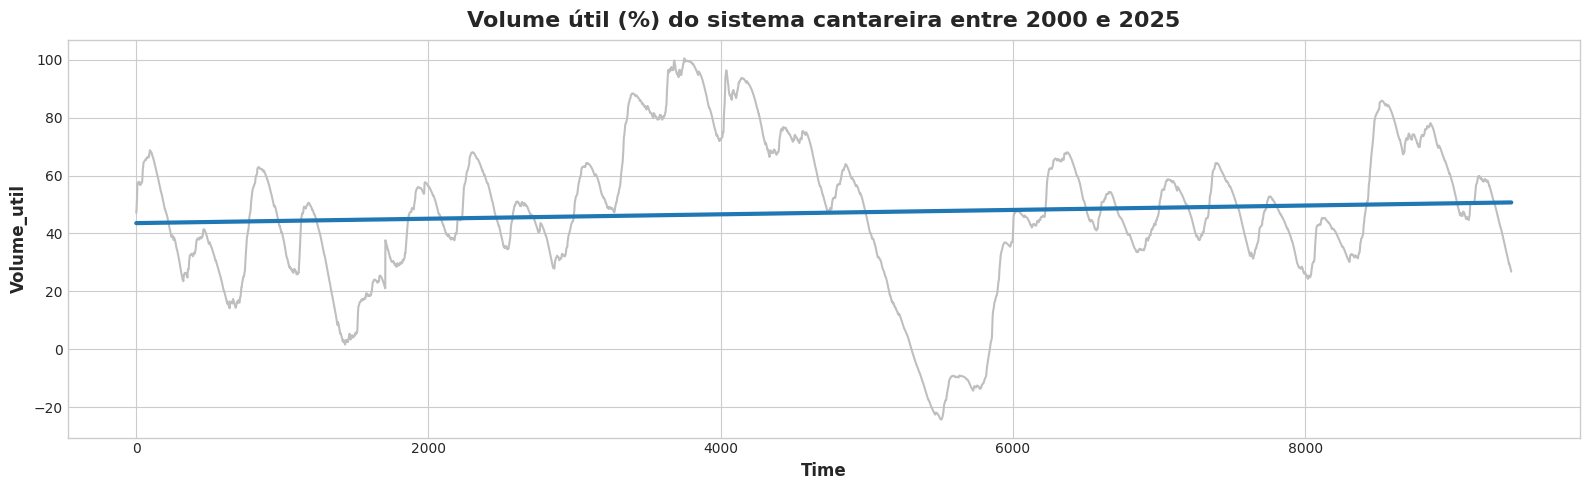

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rc(

    "figure",
    autolayout = True, 
    figsize = (11,4),
    titlesize = 18,
    titleweight = 'bold',

)

plt.rc(
    "axes",
    labelweight = 'bold',
    labelsize = "large",
    titleweight = "bold",
    titlesize = 16,
    titlepad = 10
    )

fig, ax = plt.subplots(figsize=(16,5))

ax.plot(dfv['Time'], dfv['Volume_util'], data=dfv, color= '0.75')
ax.plot (dfv['Time'], dfv['y_pred'], color='tab:blue', linewidth=3, label='Regressão Linear', zorder=3)

ax.set_title('Volume útil (%) do sistema cantareira entre 2000 e 2025')
ax.set_xlabel('Time')
ax.set_ylabel('Volume_util')

#### Visualizando a tendência por médias móveis

<Axes: title={'center': 'Volume útil do sistema cantareira em médias móveis'}, xlabel='Data'>

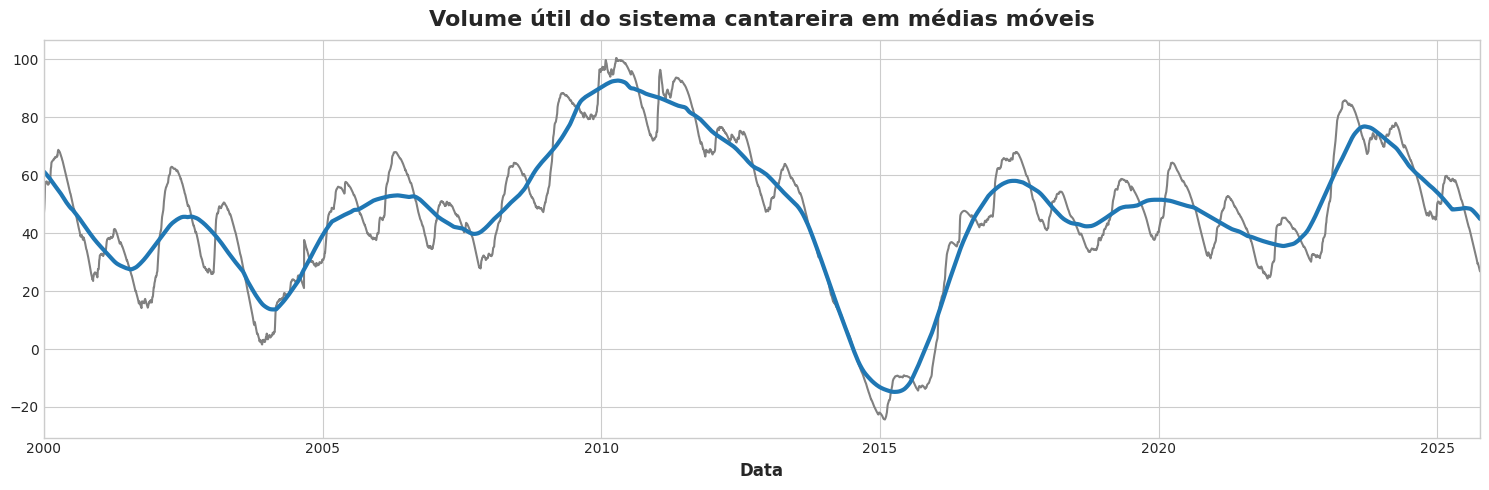

In [11]:
moving_average = dfv['Volume_util'].rolling(
    window = 365, 
    center = True, 
    min_periods = 182, 

).mean()

ax = dfv['Volume_util'].plot (style="-", color="0.5", figsize=(15,5))
moving_average.plot(
    ax=ax, linewidth=3, title = "Volume útil do sistema cantareira em médias móveis", legend=False
)

#### Tendência + Sazonalidade usando termos de Fourier 

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)

plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

%config InlineBackend.figure_format = 'retina'

def seasonal_plot (X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors = X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )

    return ax 

def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs=pd.Timedelta("365D") / pd.Timedelta("1D")
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

/tmp/ipykernel_54702/3960733576.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(


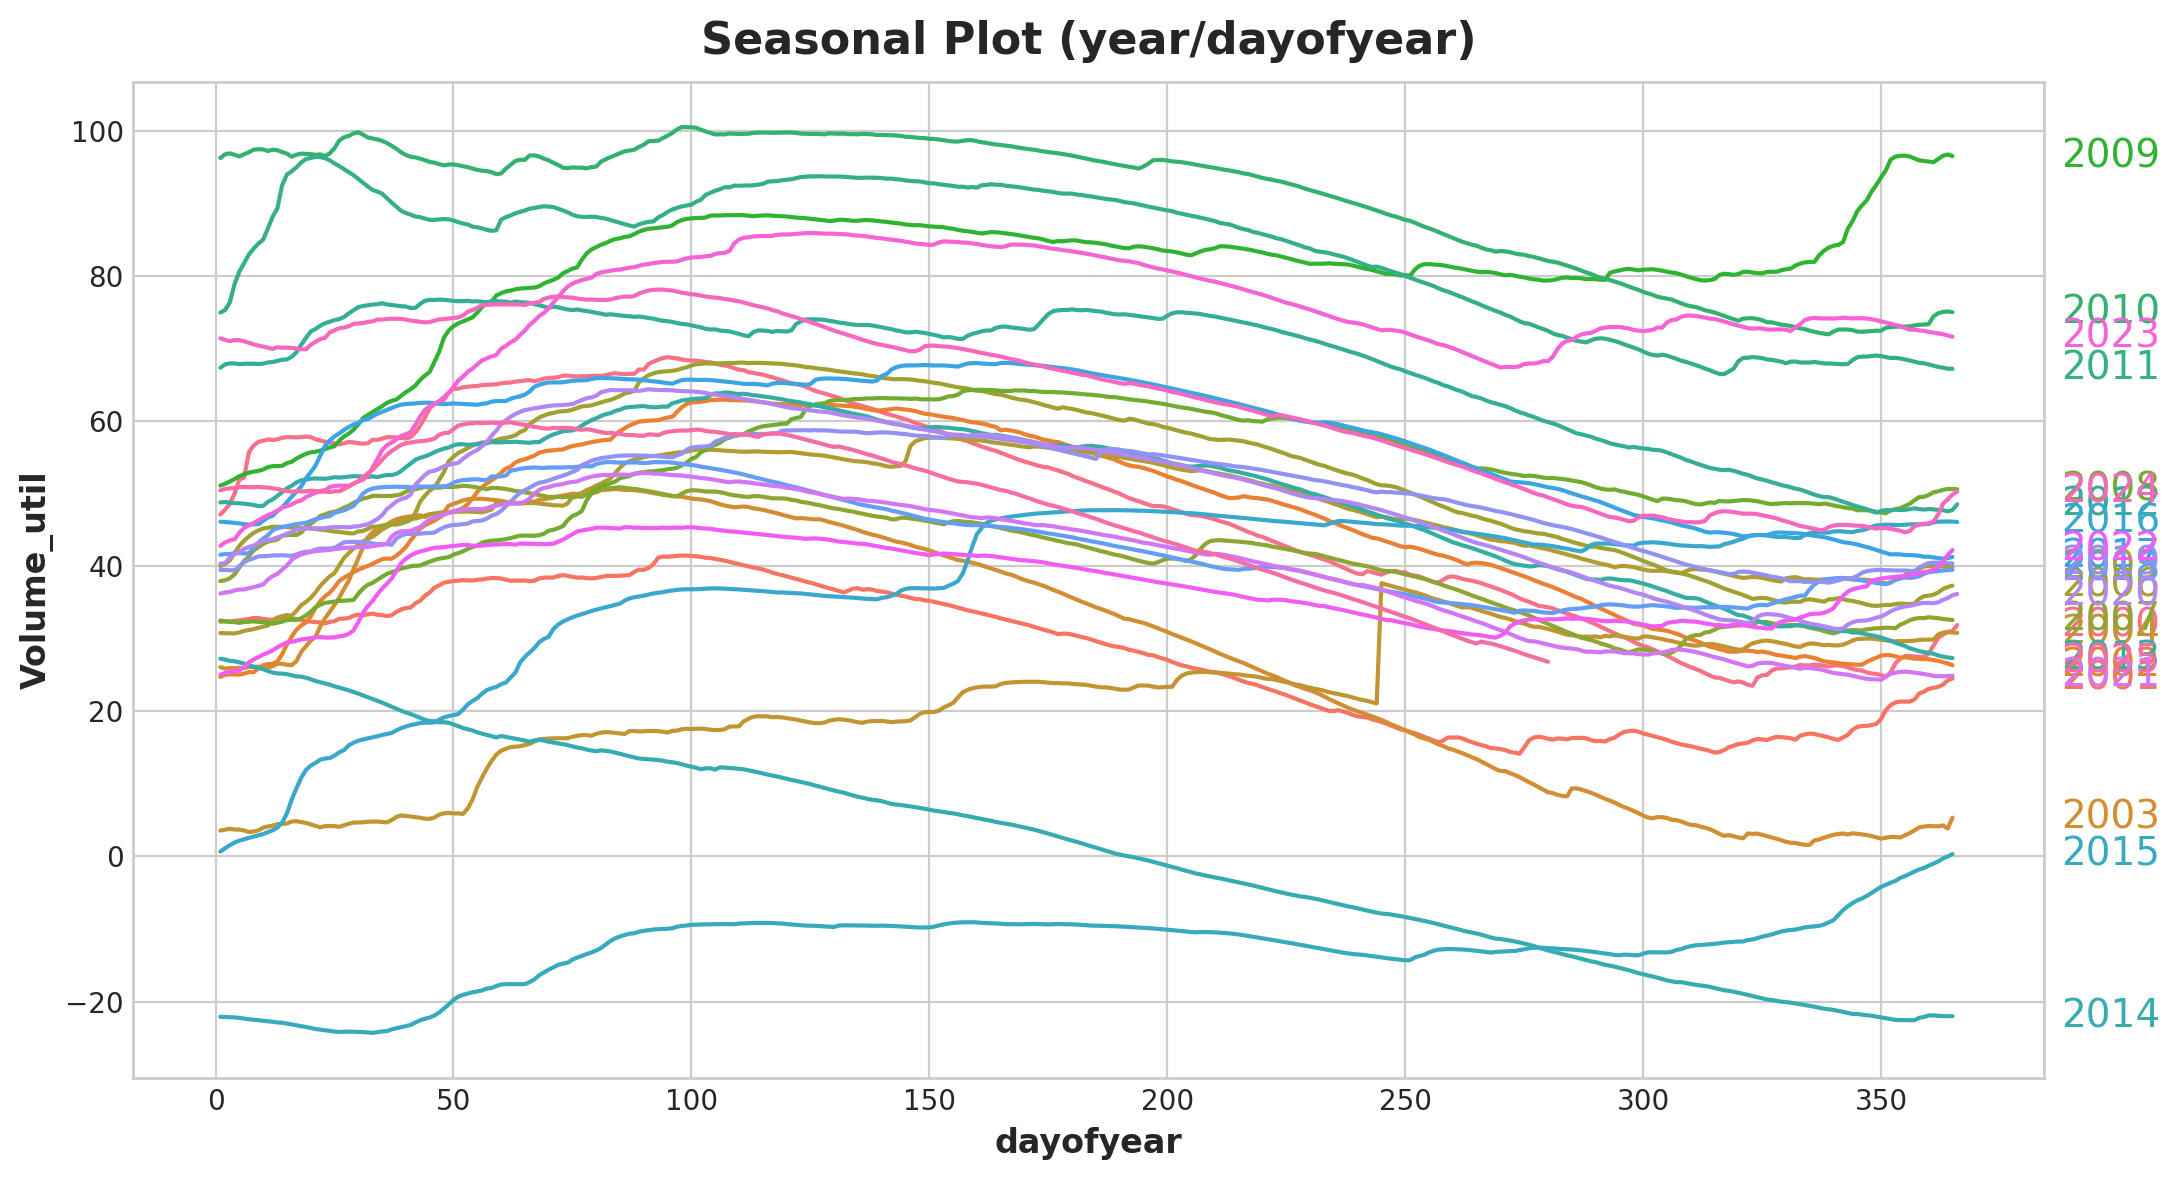

In [13]:
x1 = dfv.copy()

x1['dayofyear'] = x1.index.dayofyear
x1['year'] = x1.index.year
fig, ax = plt.subplots(figsize=(11, 6))
seasonal_plot(x1, y="Volume_util", period="year", freq="dayofyear", ax=ax);

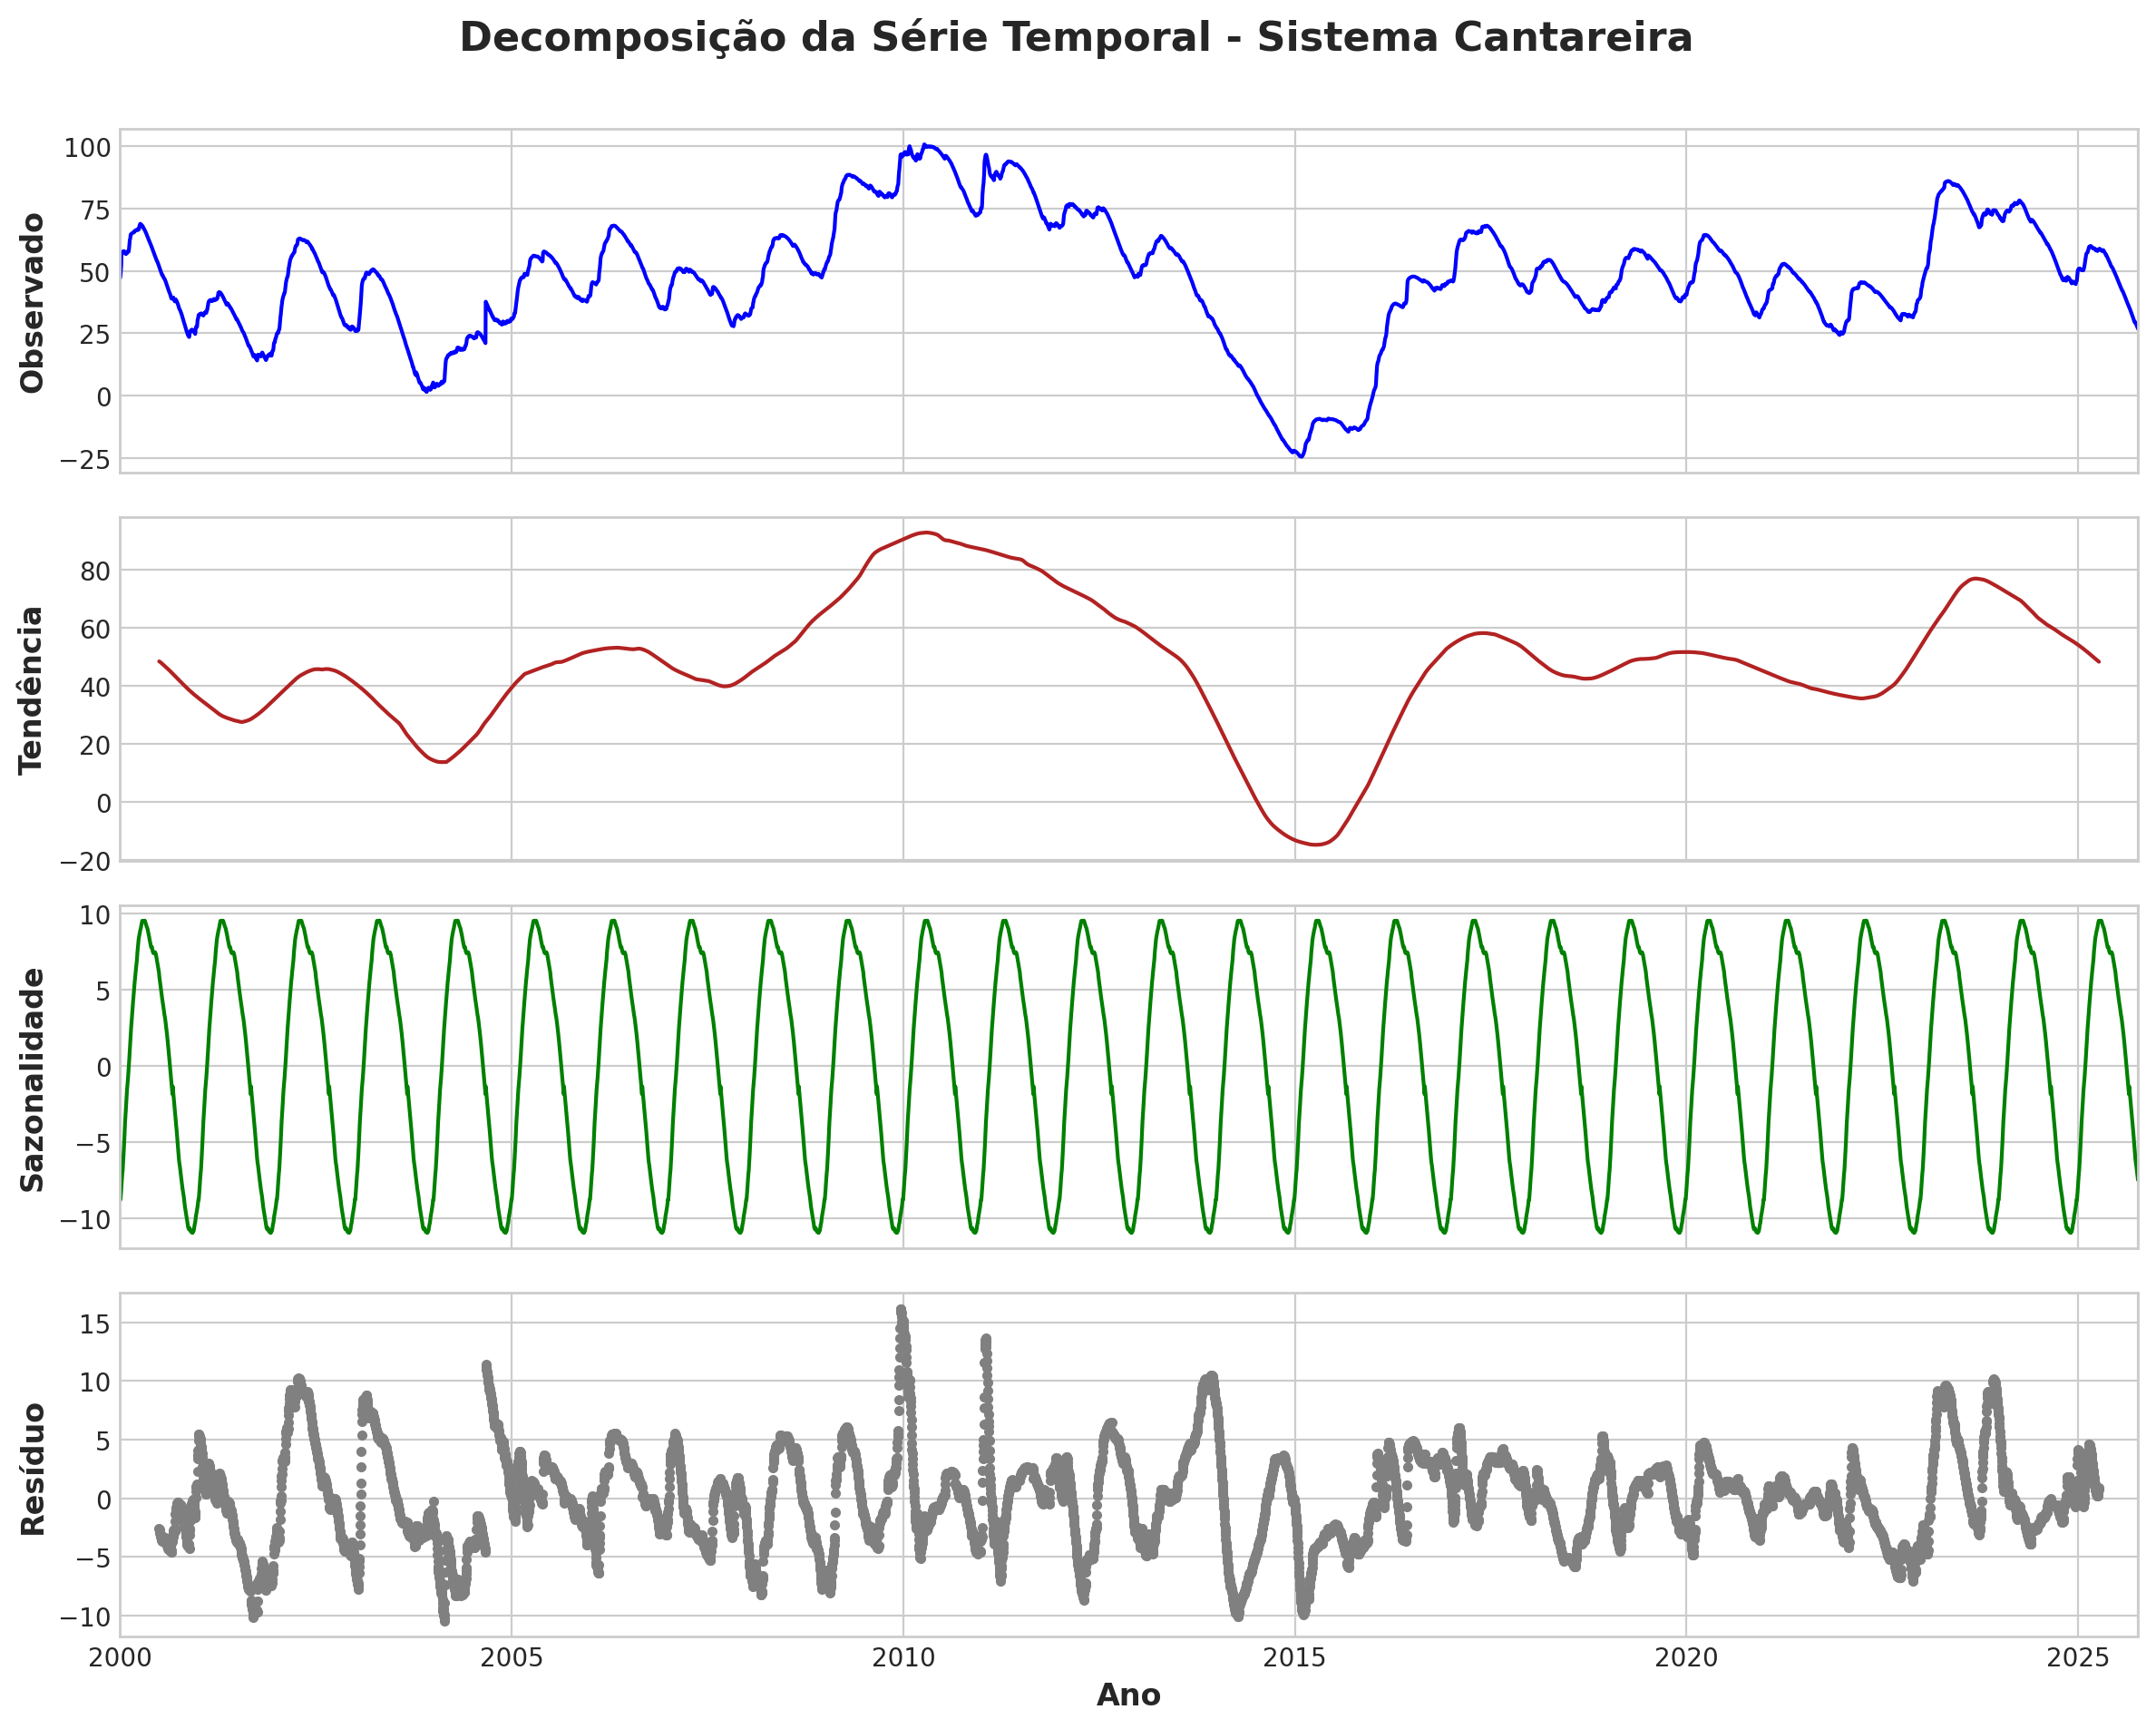

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposicao = seasonal_decompose(dfv['Volume_util'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))


decomposicao.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Observado')


decomposicao.trend.plot(ax=axes[1], color='firebrick', legend=False)
axes[1].set_ylabel('Tendência')


decomposicao.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Sazonalidade')


decomposicao.resid.plot(ax=axes[3], color='gray', legend=False, style='.')
axes[3].set_ylabel('Resíduo')


fig.suptitle('Decomposição da Série Temporal - Sistema Cantareira', fontsize=16)
plt.xlabel('Ano')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta o layout para o título principal não sobrepor os gráficos
plt.show()

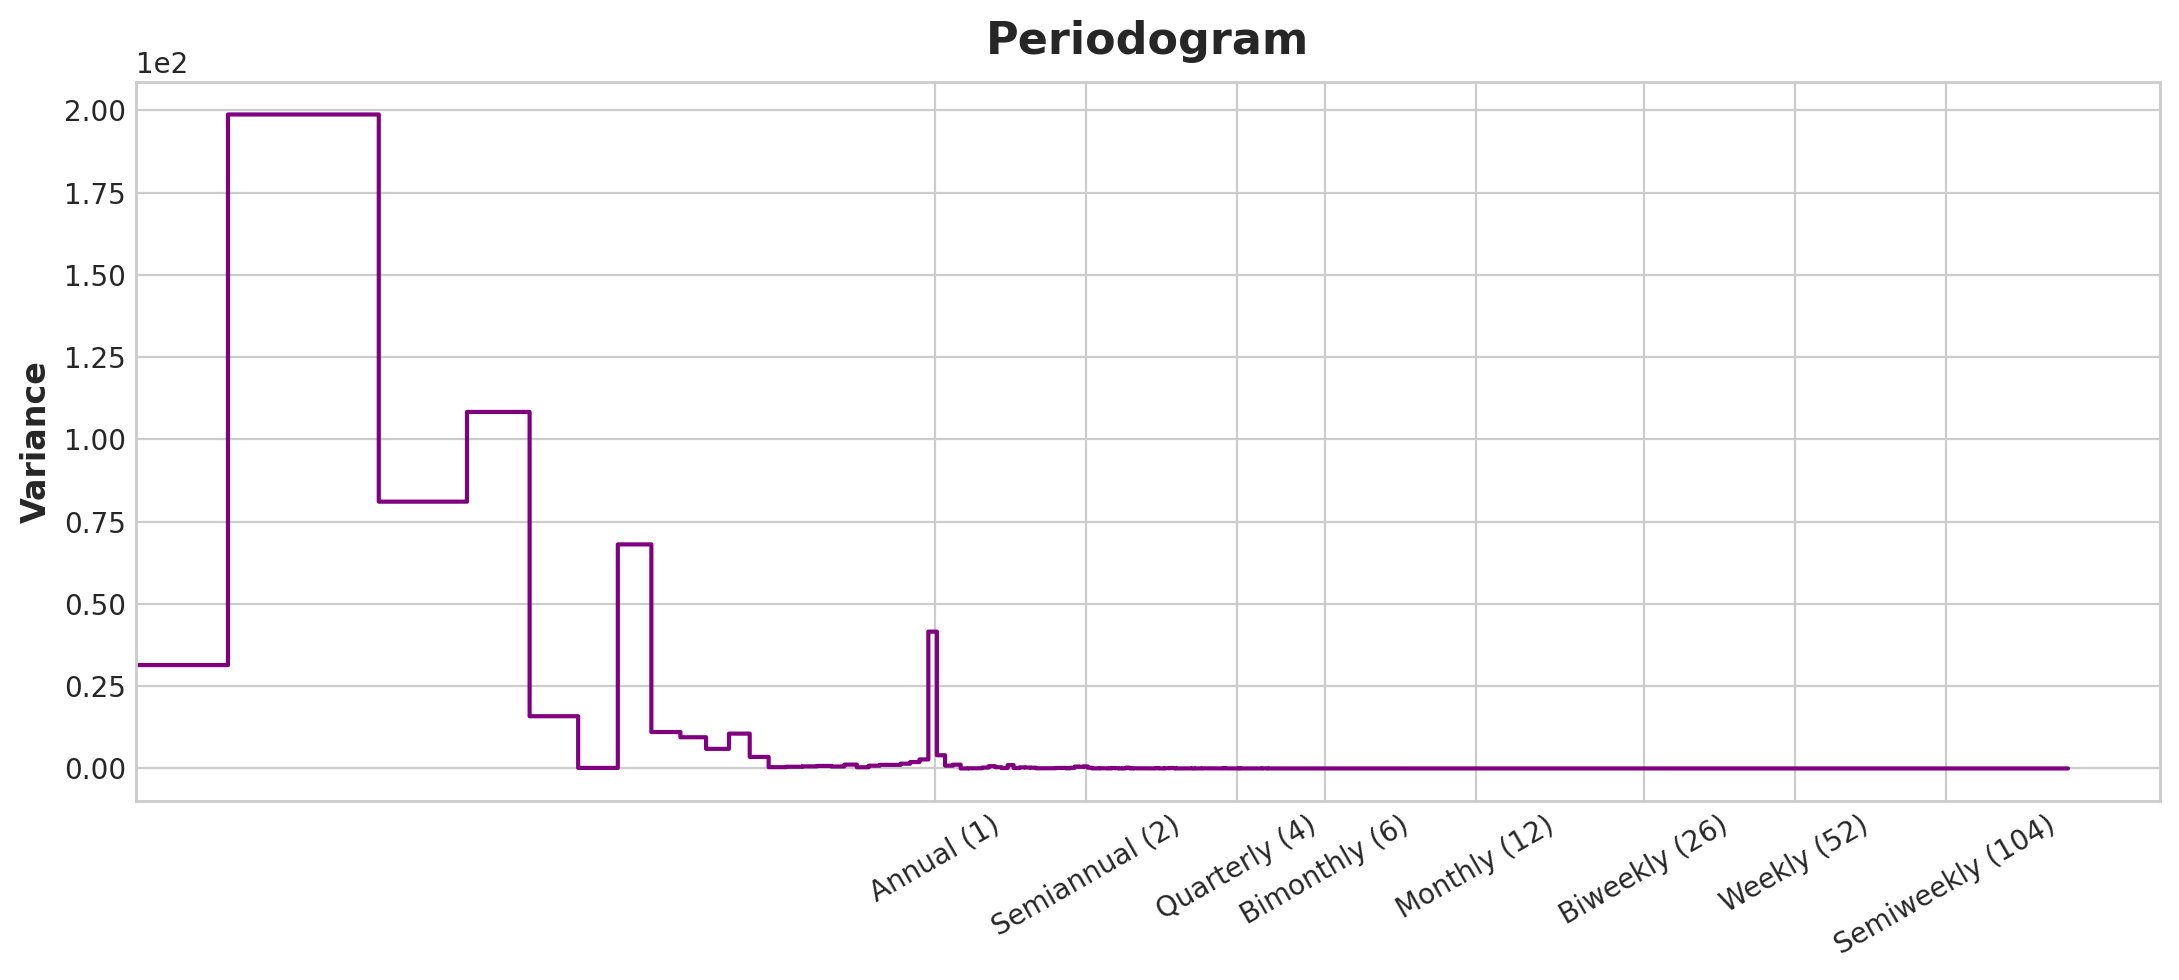

In [15]:
plot_periodogram(dfv.Volume_util);

In [16]:
dfv.head()
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Volume_util  9412 non-null   float64
 1   Time         9412 non-null   int64  
 2   y_pred       9412 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 294.1 KB


In [17]:
#prevendo tendência + sazonalidade juntas 
dfv = dfv.asfreq('D')
fourier = CalendarFourier(freq = "A", order = 4)

dp = DeterministicProcess(
    index=dfv.index,
    constant=True,               # dummy feature for bias (y-intercept)
    order=3,                     # trend (order 1 means linear)
    seasonal=True,               # weekly seasonality (indicators)
    additional_terms=[fourier],  # annual seasonality (fourier)
    drop=True,                   # drop terms to avoid collinearity
)

x1 = dp.in_sample()

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [18]:
x1.head()

,const,trend,trend_squared,trend_cubed,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)"
Data,,,,,,,,,,,,,,,,,,
2000-01-01,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2000-01-02,1.0,2.0,4.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.017166,0.999853,0.034328,0.999411,0.051479,0.998674,0.068615,0.997643
2000-01-03,1.0,3.0,9.0,27.0,0.0,1.0,0.0,0.0,0.0,0.0,0.034328,0.999411,0.068615,0.997643,0.102821,0.994700,0.136906,0.990584
2000-01-04,1.0,4.0,16.0,64.0,0.0,0.0,1.0,0.0,0.0,0.0,0.051479,0.998674,0.102821,0.994700,0.153891,0.988088,0.204552,0.978856
2000-01-05,1.0,5.0,25.0,125.0,0.0,0.0,0.0,1.0,0.0,0.0,0.068615,0.997643,0.136906,0.990584,0.204552,0.978856,0.271234,0.962513


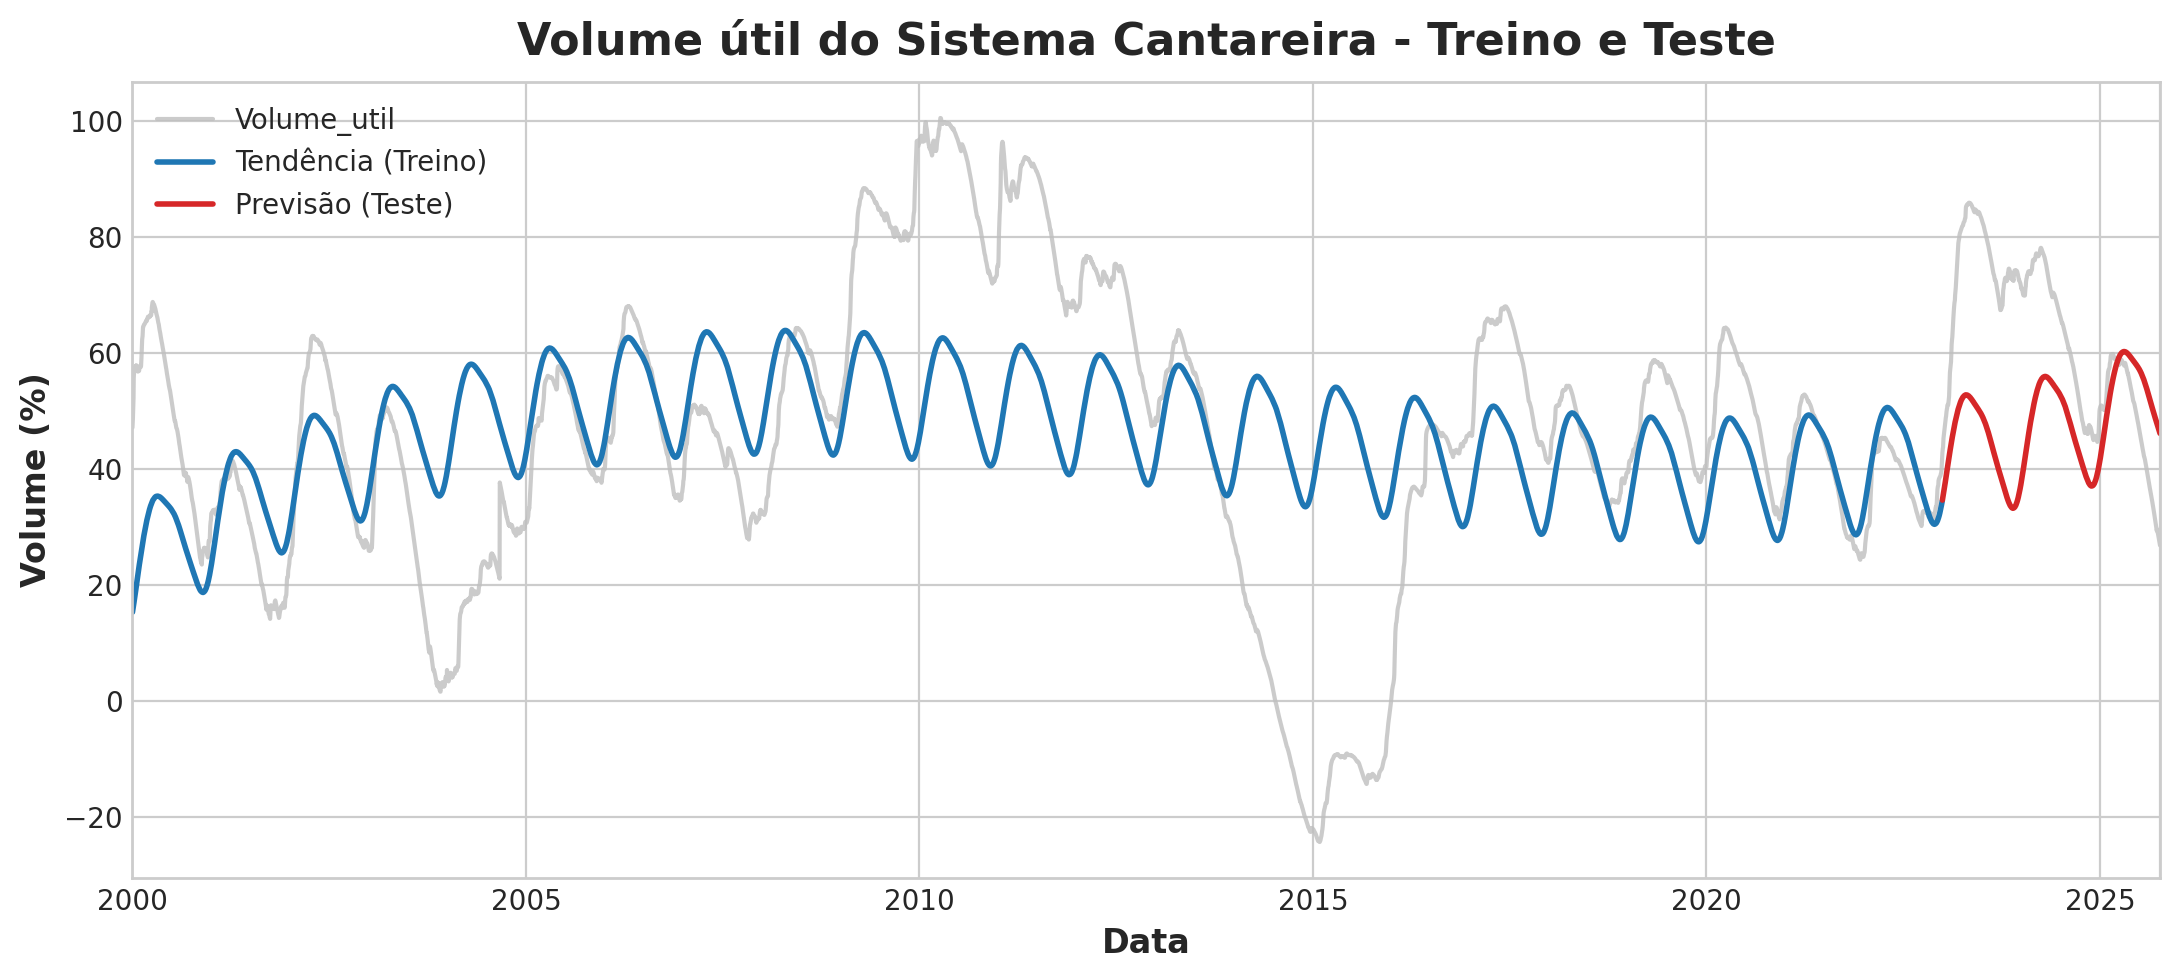

In [19]:
# Seus dados iniciais (vamos supor que x1 e y1 cobrem todo o período)
y1 = dfv["Volume_util"]
# x1 = dp.in_sample() # Supondo que x1 foi criado assim

# --- 1. Definir a data de corte e separar os dados ---
# Tudo antes de 2023 é treino, e tudo a partir de 2023 é teste.
split_date = '2023-01-01'

# Separando as features (X)
X_train = x1.loc[x1.index < split_date]
X_test = x1.loc[x1.index >= split_date]

# Separando o alvo (y)
y_train = y1.loc[y1.index < split_date]
y_test = y1.loc[y1.index >= split_date]


# --- 2. Treinar o modelo APENAS com os dados de treino ---
model1 = LinearRegression()
model1.fit(X_train, y_train)


# --- 3. Fazer previsões para os dois períodos (treino e teste) ---
# Previsão sobre os dados que o modelo viu no treino (para visualização)
y_pred_train = pd.Series(model1.predict(X_train), index=X_train.index)

# Previsão sobre os dados de teste (a avaliação real do modelo)
y_pred_test = pd.Series(model1.predict(X_test), index=X_test.index)


# --- 4. Visualizar os resultados ---
fig, ax = plt.subplots() # Criando a figura e os eixos para o gráfico

# Plotar a série temporal completa (treino + teste) em cinza como referência
ax = y1.plot(color='0.75', style='-', 
             title="Volume útil do Sistema Cantareira - Treino e Teste",
             ylabel="Volume (%)",
             alpha=0.8)

# Plotar a linha de tendência que o modelo aprendeu com os dados de treino
ax = y_pred_train.plot(ax=ax, label="Tendência (Treino)", linewidth=2)

# Plotar a previsão (forecast) para o período de teste
ax = y_pred_test.plot(ax=ax, label="Previsão (Teste)", color='C3', linewidth=2)

# Adicionar a legenda
_ = ax.legend()

In [34]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style="-.",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig


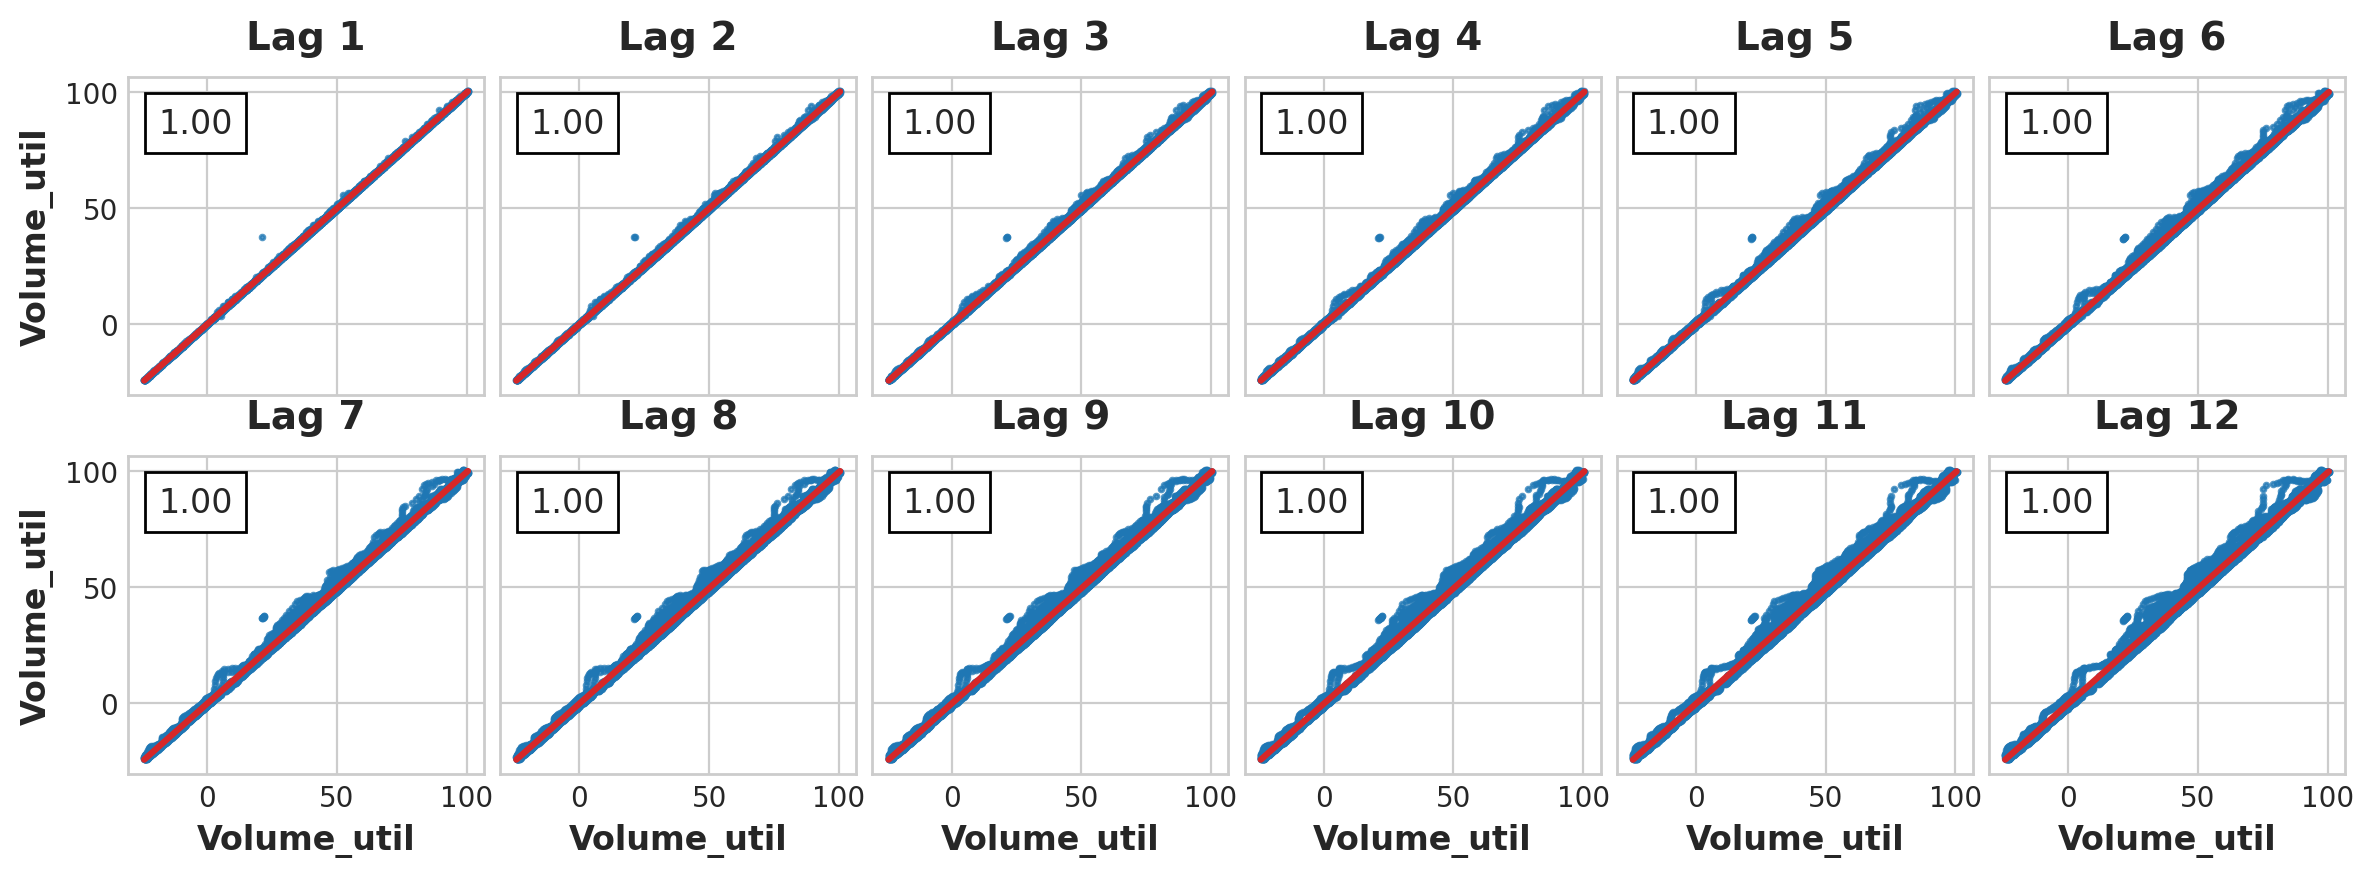

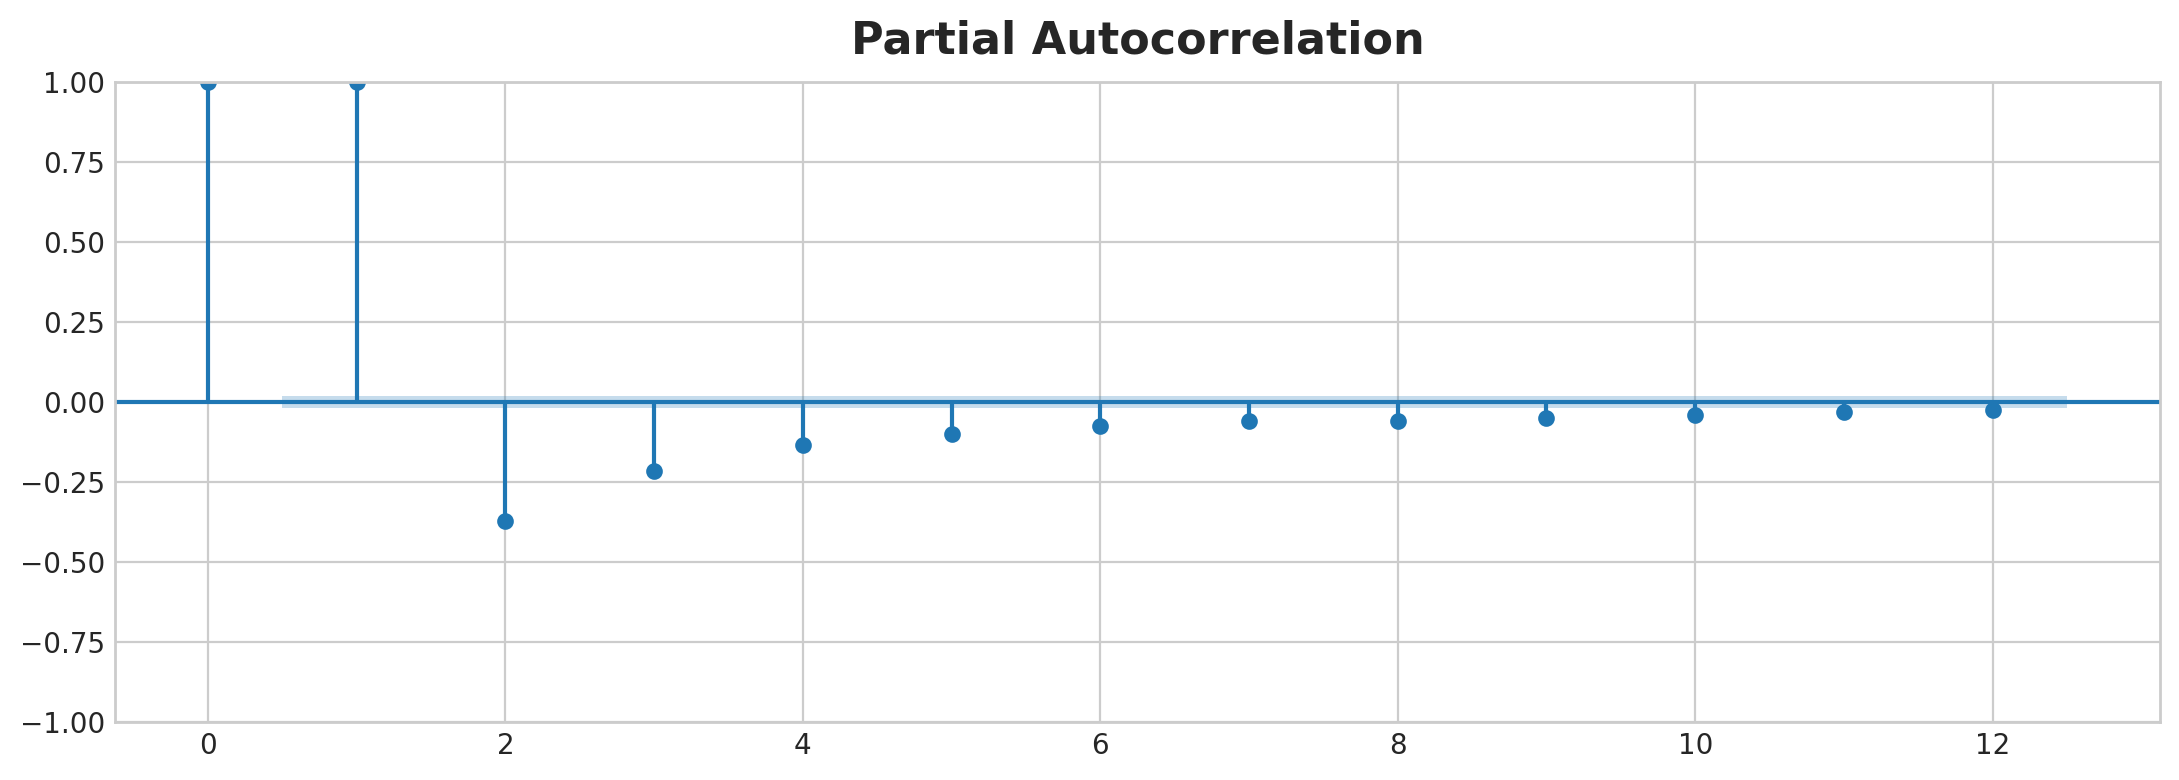

In [35]:
_ = plot_lags(dfv.Volume_util, lags=12, nrows=2)
_ = plot_pacf(dfv.Volume_util, lags=12)

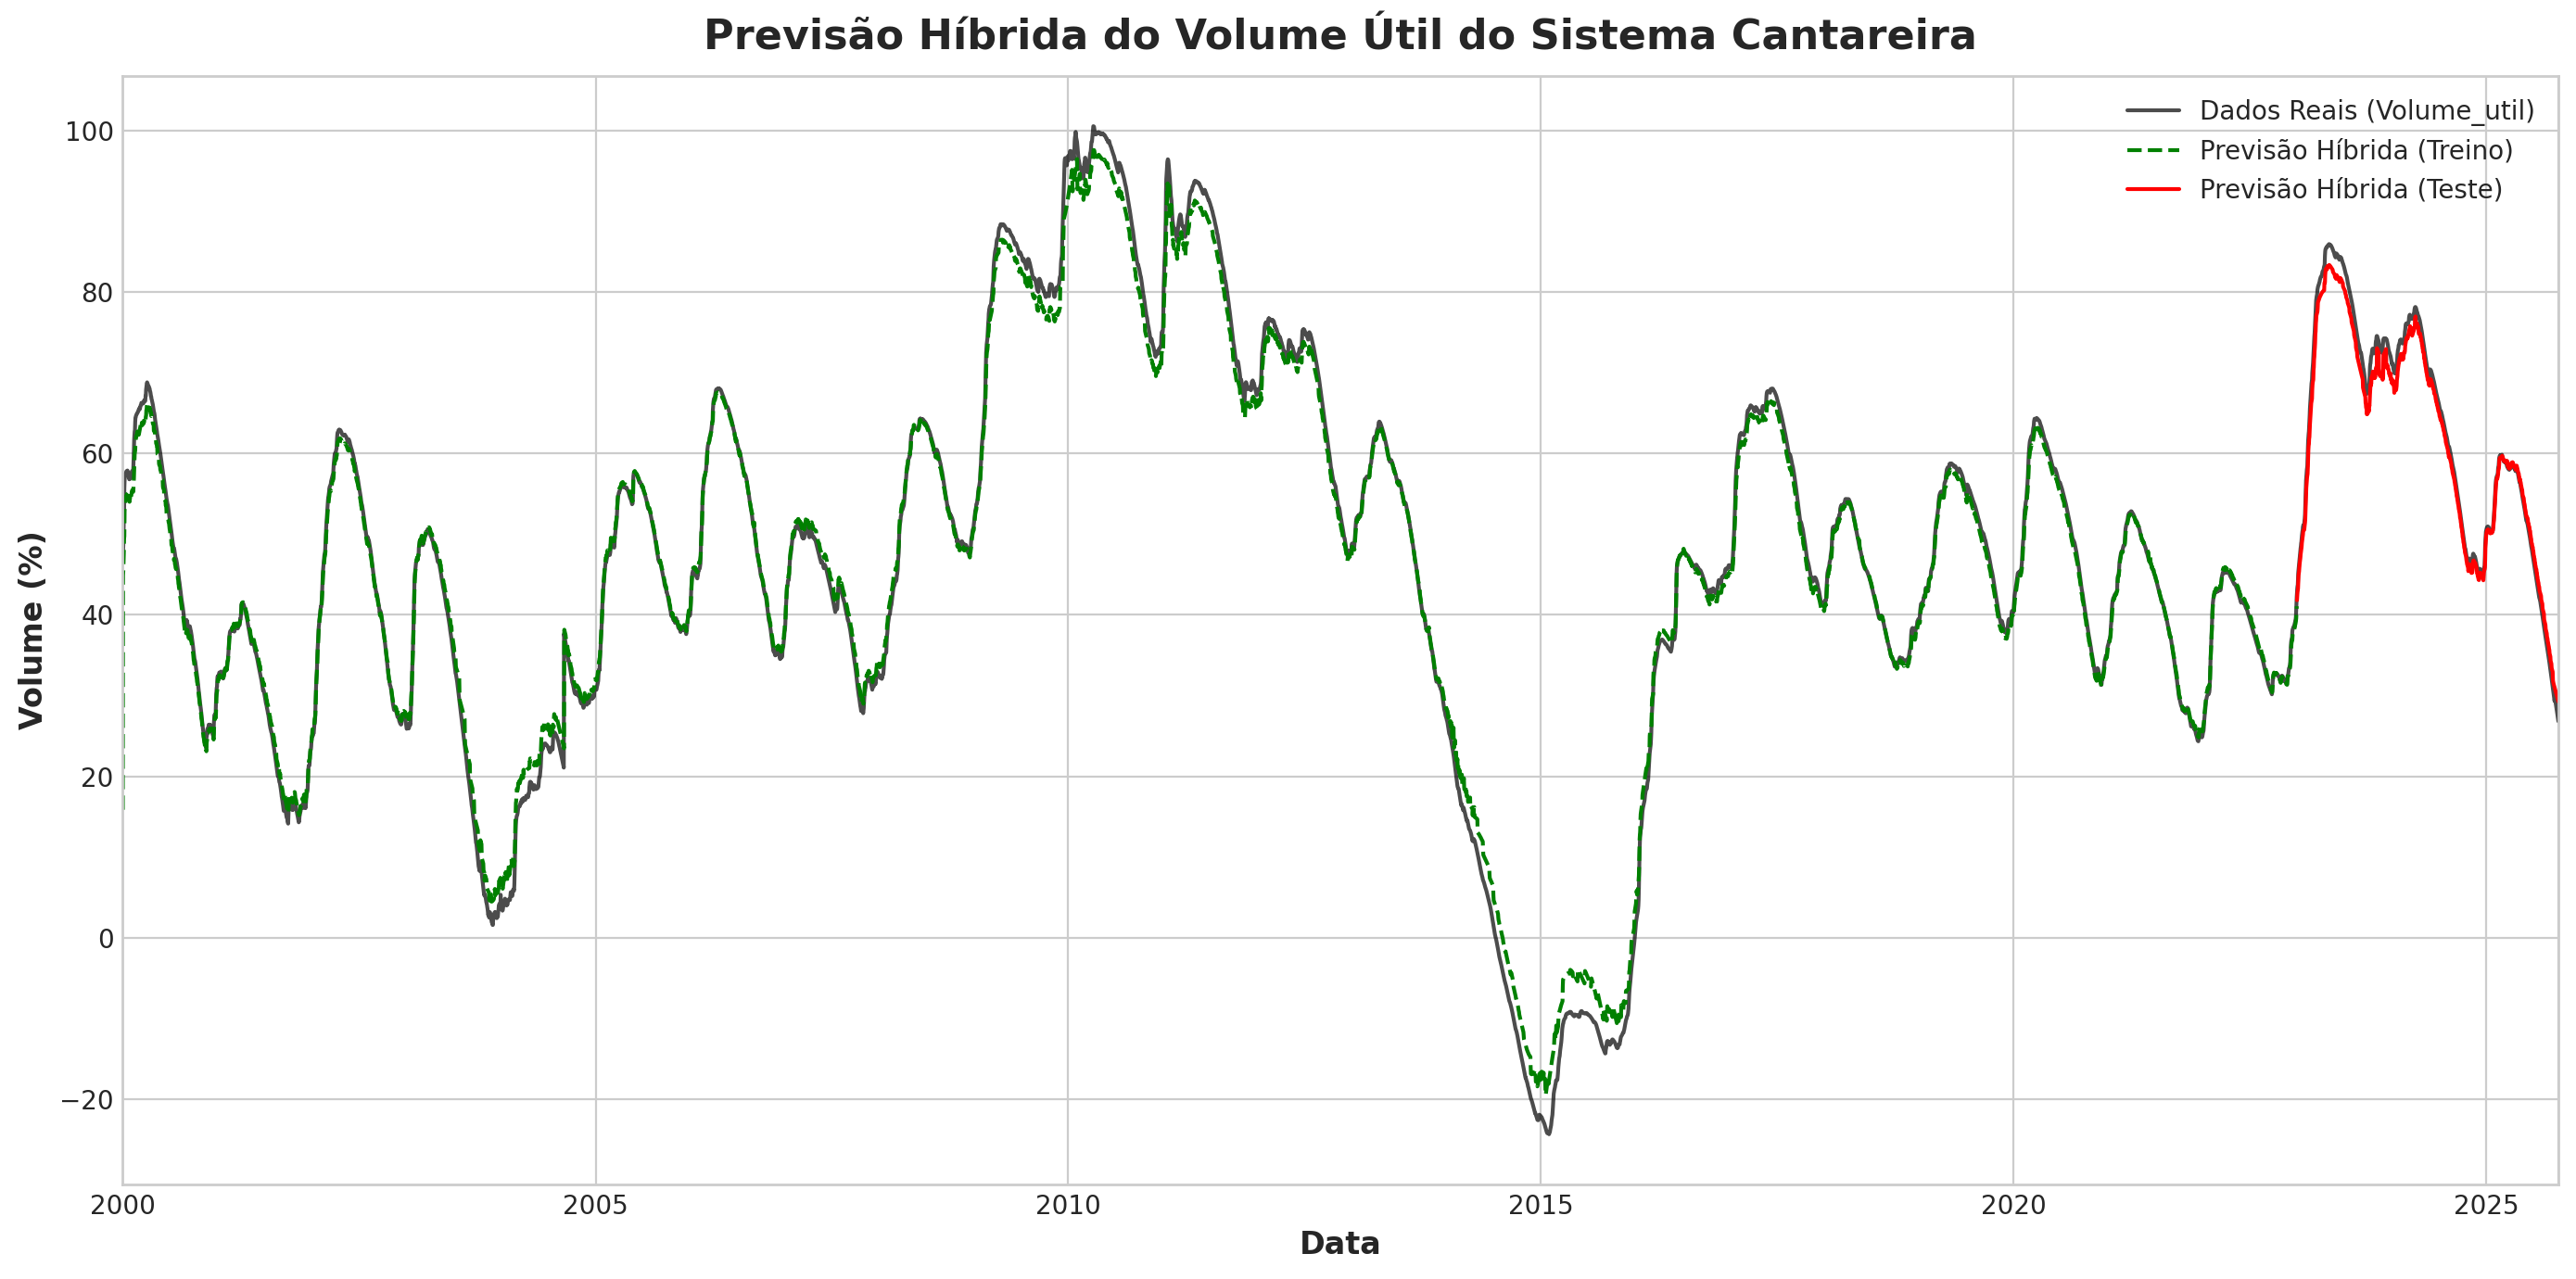

In [20]:


# --- 1. Calcular os Resíduos do Primeiro Modelo ---
# Resíduos = Valores Reais - Previsões do Modelo 1
# Fazemos isso separadamente para treino e teste.

# Resíduos no período de treino
y_res_train = y_train - y_pred_train 

# Resíduos no período de teste
y_res_test = y_test - y_pred_test

# Concatenamos para facilitar a criação das features de lag
y_res = pd.concat([y_res_train, y_res_test])


# --- 2. Criar Features para o Segundo Modelo (XGBoost) ---
# A função para criar lags que você já tinha
def make_lags(ts, lags):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)

# Criando as features de lag a partir da série de resíduos completa
x2 = make_lags(y_res, lags=2)
x2 = x2.fillna(0.0) # Preenchendo os valores nulos iniciais


# --- 3. Separar os Novos Dados (x2 e y_res) em Treino e Teste ---
# Usamos a mesma data de corte para garantir consistência
split_date = '2023-01-01'

X2_train = x2.loc[x2.index < split_date]
X2_test = x2.loc[x2.index >= split_date]

# O alvo para este segundo modelo são os próprios resíduos
# y_res_train e y_res_test já foram criados no passo 1.


# --- 4. Treinar o Modelo XGBoost APENAS nos Resíduos de Treino ---
model2 = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0) 
model2.fit(X2_train, y_res_train)


# --- 5. Fazer Previsões dos Resíduos ---
# Prever os resíduos para o período de treino
y_pred_res_train = pd.Series(model2.predict(X2_train), index=X2_train.index)

# Prever os resíduos para o período de teste (forecast)
y_pred_res_test = pd.Series(model2.predict(X2_test), index=X2_test.index)


# --- 6. Criar a Previsão Híbrida Final ---
# Previsão Final = Previsão do Modelo 1 + Previsão dos Resíduos
y_final_train = y_pred_train + y_pred_res_train
y_final_test = y_pred_test + y_pred_res_test


# --- 7. Visualização Limpa do Resultado Final ---
fig, ax = plt.subplots(figsize=(14, 7))

# Plotar os dados reais da série temporal completa
y1.plot(ax=ax, color='black', alpha=0.7, style='-', label='Dados Reais (Volume_util)')

# Plotar a previsão híbrida final sobre os dados de treino
y_final_train.plot(ax=ax, color='green', linestyle='--', label='Previsão Híbrida (Treino)')

# Plotar a previsão híbrida final sobre os dados de teste
y_final_test.plot(ax=ax, color='red', linestyle='-', label='Previsão Híbrida (Teste)')

ax.set_title('Previsão Híbrida do Volume Útil do Sistema Cantareira')
ax.set_ylabel('Volume (%)')
ax.legend()
plt.show()

#### Considerando apenas o periodo entre 2016 e 2023

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


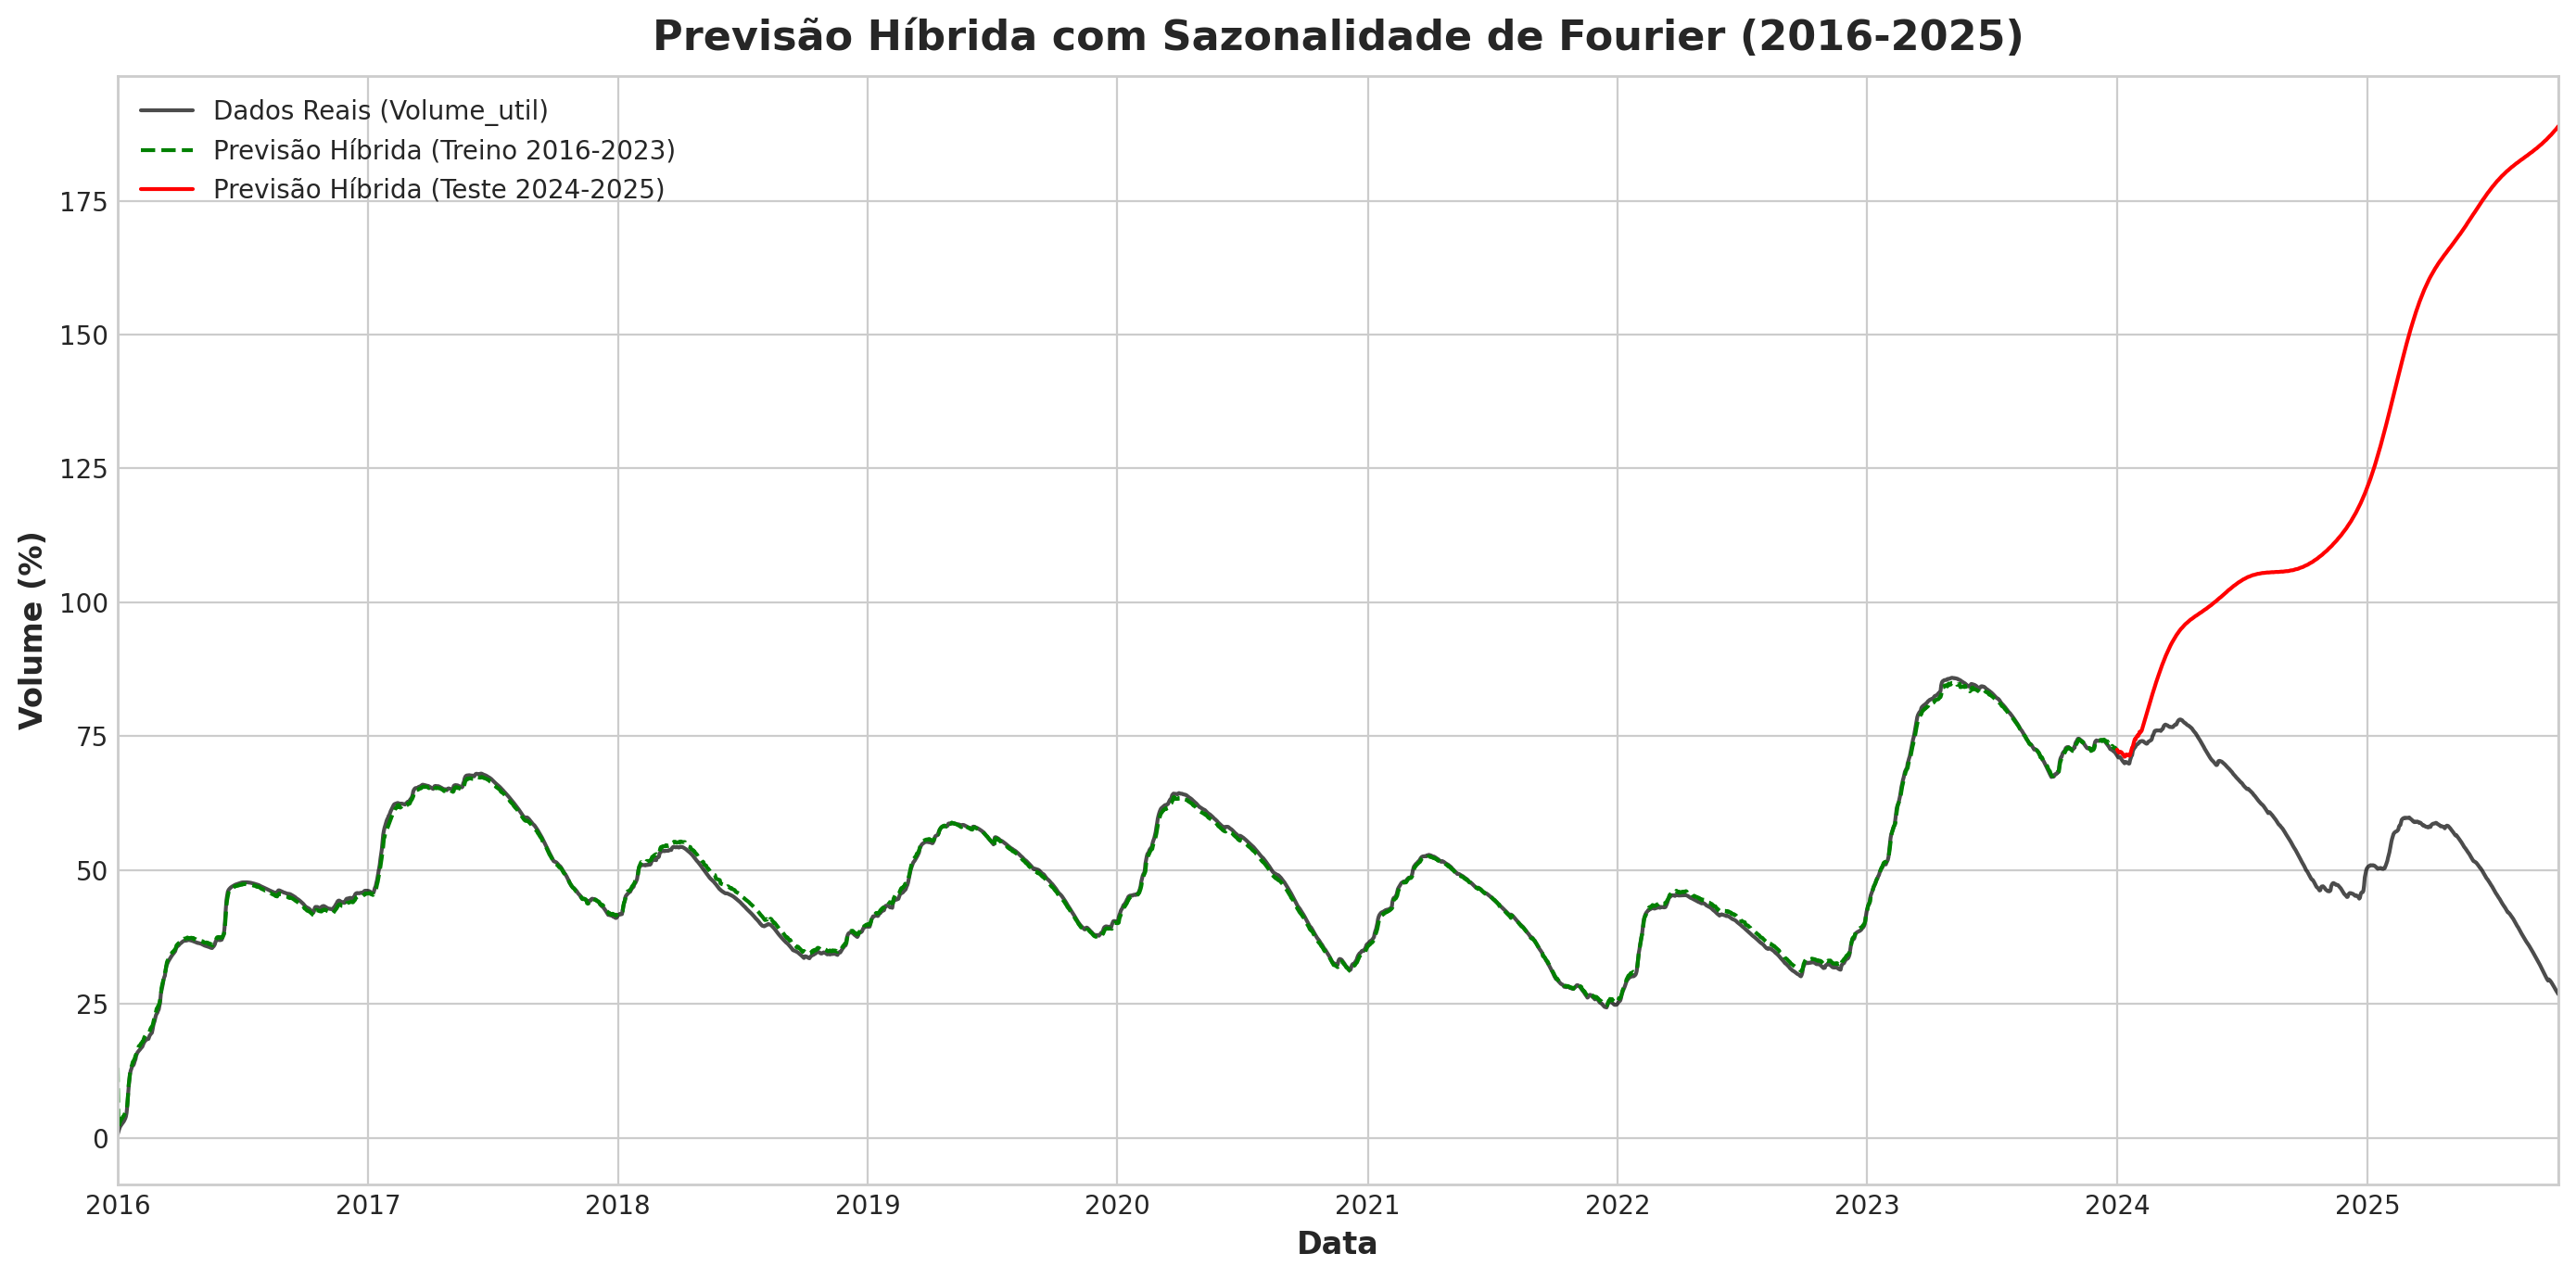

In [21]:


# --- 1. Preparação de Dados com o Novo DeterministicProcess ---

# Garantir que o DataFrame tenha frequência diária, preenchendo datas ausentes
# Se seus dados já são diários e completos, esta linha não mudará nada.
dfv = dfv.asfreq('D')

# Filtrar para o período de interesse (2016-2025)
df_periodo = dfv.loc['2016-01-01':'2025-12-31'].copy()

# A série alvo. Se `asfreq` criou NaNs, é uma boa ideia preenchê-los.
# Ex: y1 = df_periodo["Volume_util"].interpolate(method='linear')
y1 = df_periodo["Volume_util"]

# SEU CÓDIGO INTEGRADO AQUI:
# Usando DeterministicProcess com tendência cúbica e sazonalidade de Fourier
fourier = CalendarFourier(freq="A", order=4)
dp = DeterministicProcess(
    index=y1.index,
    constant=True,               # Intercepto
    order=3,                     # Tendência cúbica
    seasonal=True,               # Sazonalidade semanal (dummy DOW)
    additional_terms=[fourier],  # Sazonalidade anual (Fourier)
    drop=True,
)
x1 = dp.in_sample()

# Nova data de corte para a divisão treino/teste
split_date = '2024-01-01'

# Divisão das features (X) e do alvo (y) para o Modelo 1
X_train = x1.loc[x1.index < split_date]
X_test = x1.loc[x1.index >= split_date]

y_train = y1.loc[y1.index < split_date]
y_test = y1.loc[y1.index >= split_date]

# --- 2. Modelo 1: Regressão Linear (Tendência + Sazonalidade) ---

model1 = LinearRegression()
model1.fit(X_train, y_train)

# Previsões da tendência+sazonalidade para treino e teste
y_pred_train = pd.Series(model1.predict(X_train), index=X_train.index)
y_pred_test = pd.Series(model1.predict(X_test), index=X_test.index)

# --- 3. Calcular Resíduos e Preparar Dados para o Modelo 2 ---

y_res_train = y_train - y_pred_train 
y_res_test = y_test - y_pred_test
y_res = pd.concat([y_res_train, y_res_test])

def make_lags(ts, lags):
    return pd.concat(
        {f'y_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

x2 = make_lags(y_res, lags=2)
x2 = x2.fillna(0.0)

X2_train = x2.loc[x2.index < split_date]
X2_test = x2.loc[x2.index >= split_date]

# --- 4. Modelo 2: XGBoost para os Resíduos ---

model2 = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0) 
model2.fit(X2_train, y_res_train)

y_pred_res_train = pd.Series(model2.predict(X2_train), index=X2_train.index)
y_pred_res_test = pd.Series(model2.predict(X2_test), index=X2_test.index)

# --- 5. Criar a Previsão Híbrida Final ---

y_final_train = y_pred_train + y_pred_res_train
y_final_test = y_pred_test + y_pred_res_test

# --- 6. Visualização Final (Período 2016-2025) ---

fig, ax = plt.subplots(figsize=(14, 7))

y1.plot(ax=ax, color='black', alpha=0.7, style='-', label='Dados Reais (Volume_util)')
y_final_train.plot(ax=ax, color='green', linestyle='--', label='Previsão Híbrida (Treino 2016-2023)')
y_final_test.plot(ax=ax, color='red', linestyle='-', label='Previsão Híbrida (Teste 2024-2025)')

ax.set_title('Previsão Híbrida com Sazonalidade de Fourier (2016-2025)')
ax.set_ylabel('Volume (%)')
ax.legend()
plt.show()

In [73]:
df_treino = dfv.loc['2016-01-01':'2023-12-31']
df_teste = dfv.loc['2024-01-01':]

print(f"Último dado de treino: {df_treino.index.max().date()}")
print(f"Primeiro dado de teste: {df_teste.index.min().date()}")

Último dado de treino: 2023-12-31
Primeiro dado de teste: 2024-01-01


In [74]:
df_treino

,Volume_util,Time,y_pred
Data,,,
2016-01-01,0.66920,5844,48.022175
2016-01-02,1.12035,5845,48.022935
2016-01-03,1.54754,5846,48.023694
2016-01-04,1.91442,5847,48.024453
2016-01-05,2.16862,5848,48.025213
...,...,...,...
2023-12-27,72.18452,8761,50.236980
2023-12-28,72.06991,8762,50.237739
2023-12-29,71.97895,8763,50.238498


In [75]:
df_teste

,Volume_util,Time,y_pred
Data,,,
2024-01-01,71.39608,8766,50.240776
2024-01-02,71.19055,8767,50.241536
2024-01-03,71.00909,8768,50.242295
2024-01-04,71.14376,8769,50.243054
2024-01-05,71.14046,8770,50.243813
...,...,...,...
2025-10-03,27.65267,9407,50.727471
2025-10-04,27.45230,9408,50.728231
2025-10-05,27.25127,9409,50.728990


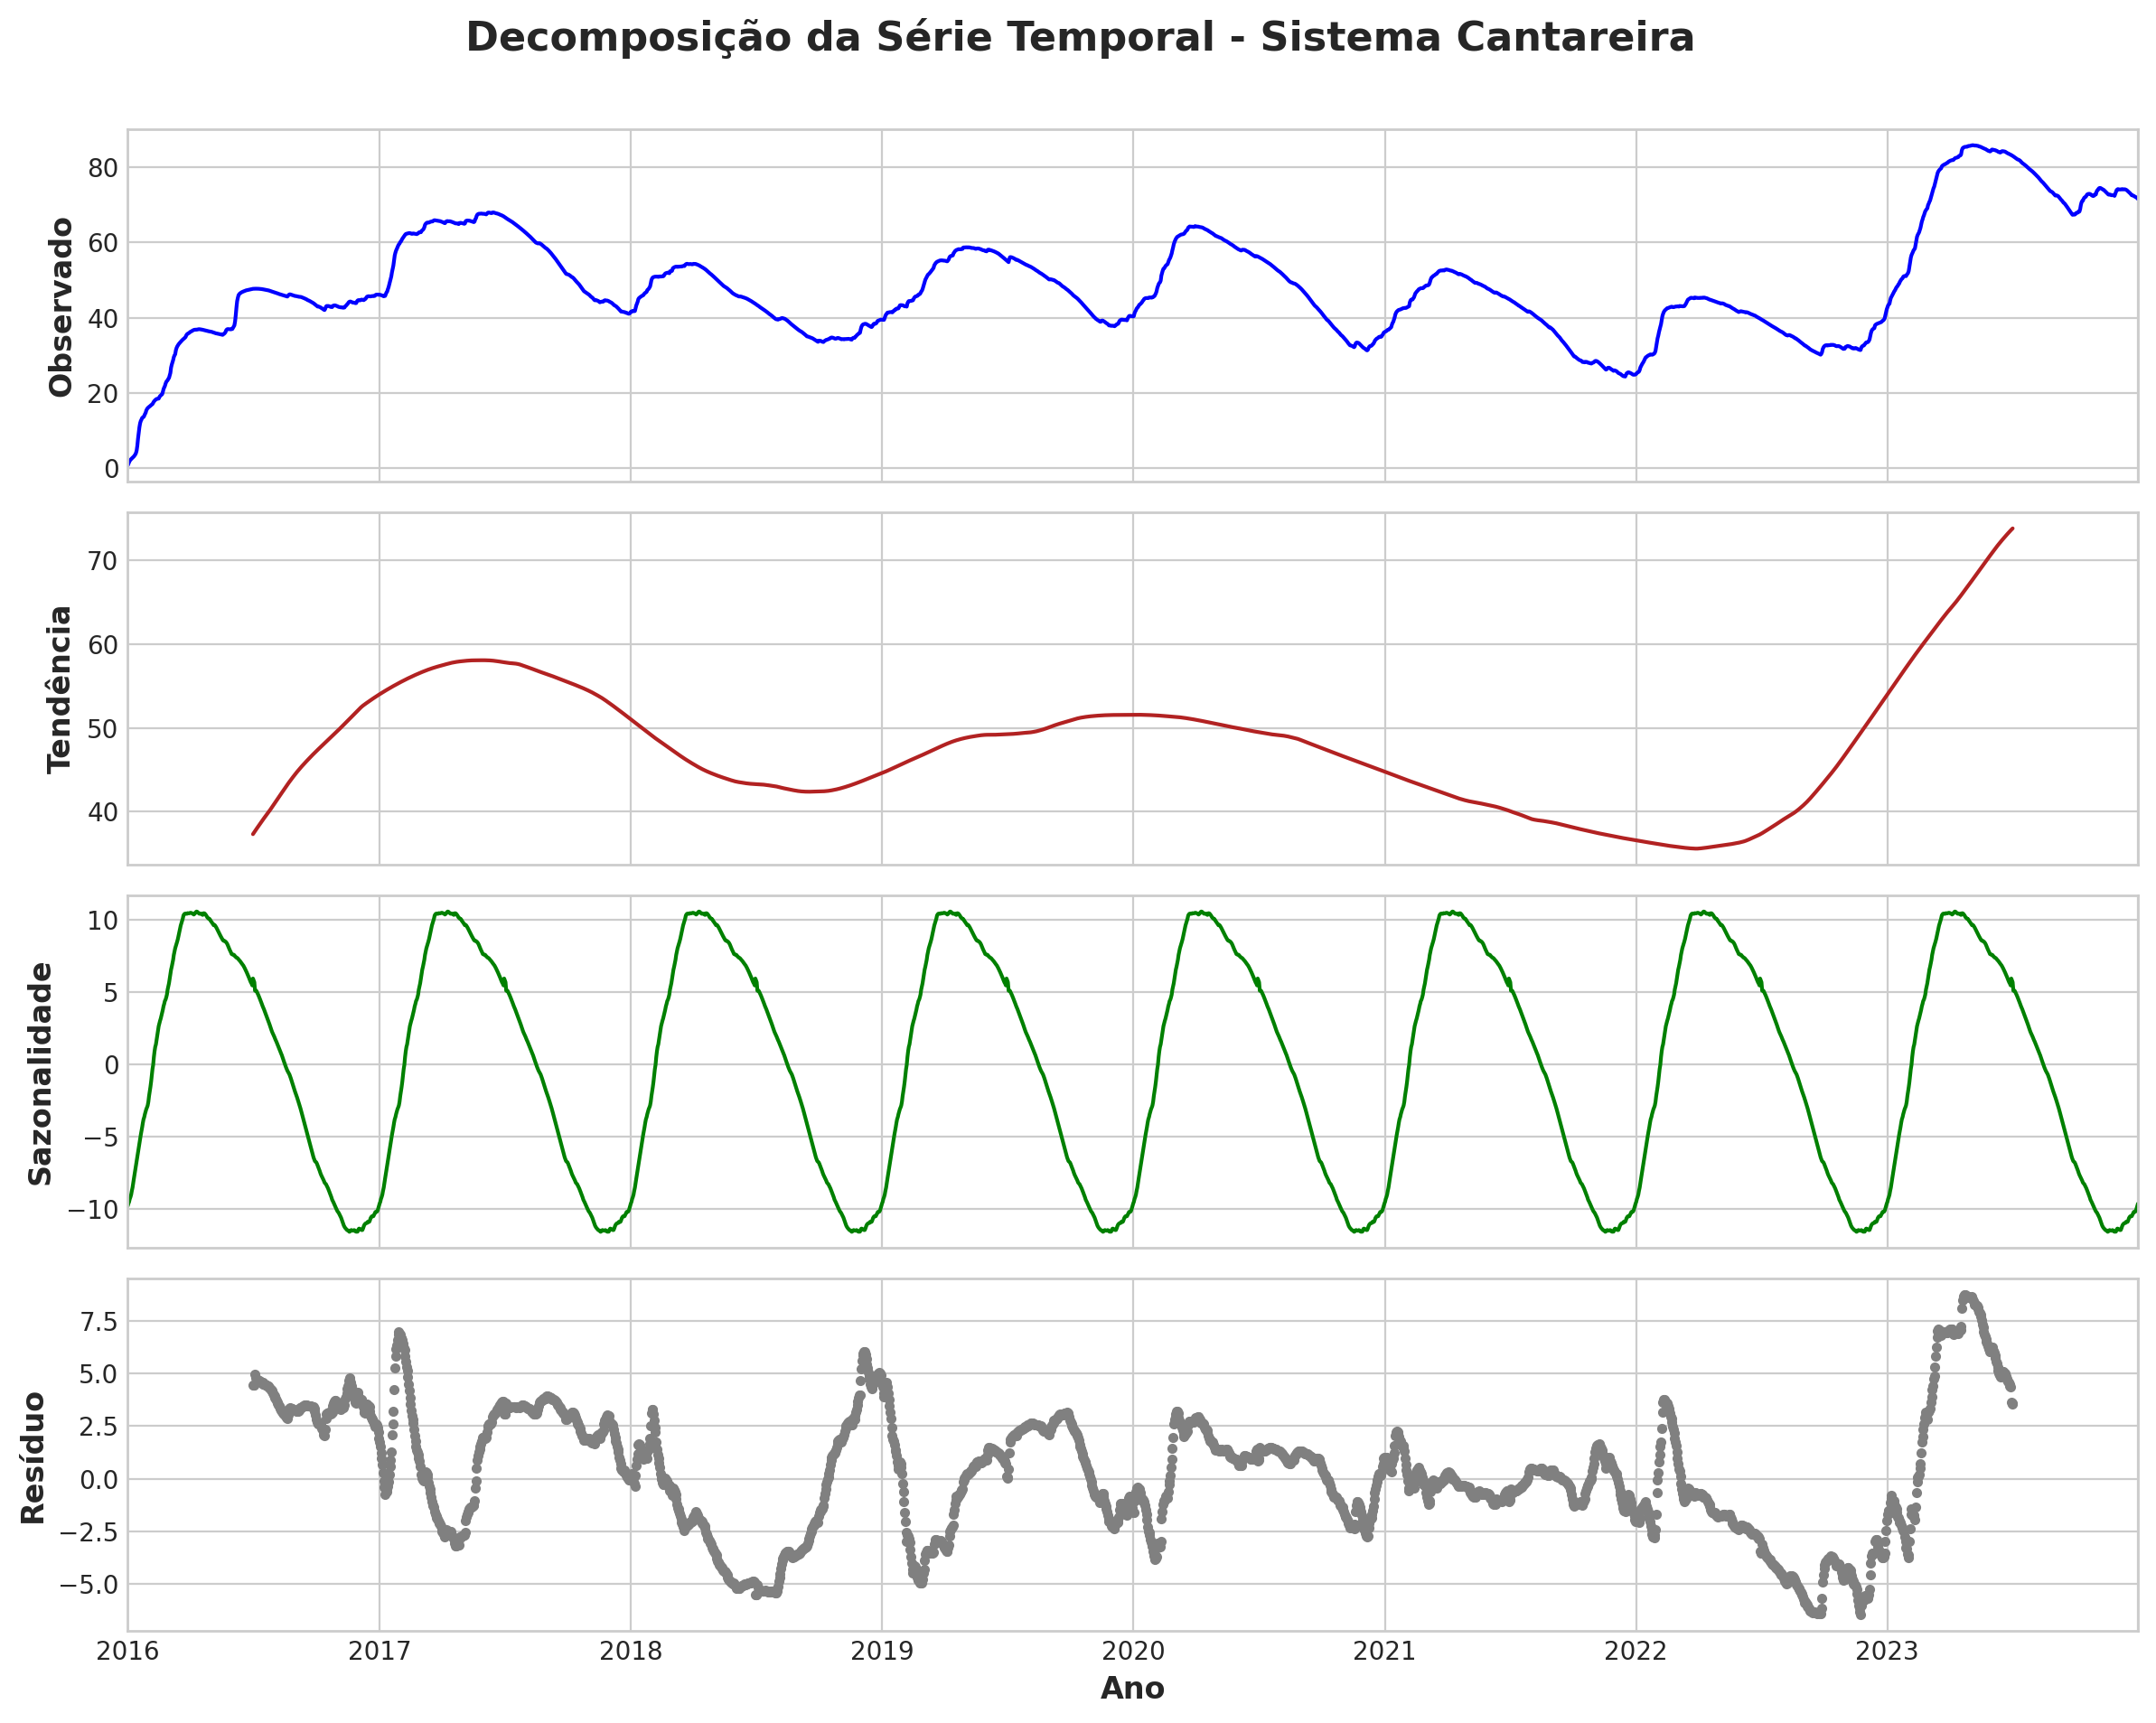

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposicao = seasonal_decompose(df_treino['Volume_util'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))


decomposicao.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Observado')


decomposicao.trend.plot(ax=axes[1], color='firebrick', legend=False)
axes[1].set_ylabel('Tendência')


decomposicao.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Sazonalidade')


decomposicao.resid.plot(ax=axes[3], color='gray', legend=False, style='.')
axes[3].set_ylabel('Resíduo')


fig.suptitle('Decomposição da Série Temporal - Sistema Cantareira', fontsize=16)
plt.xlabel('Ano')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta o layout para o título principal não sobrepor os gráficos
plt.show()

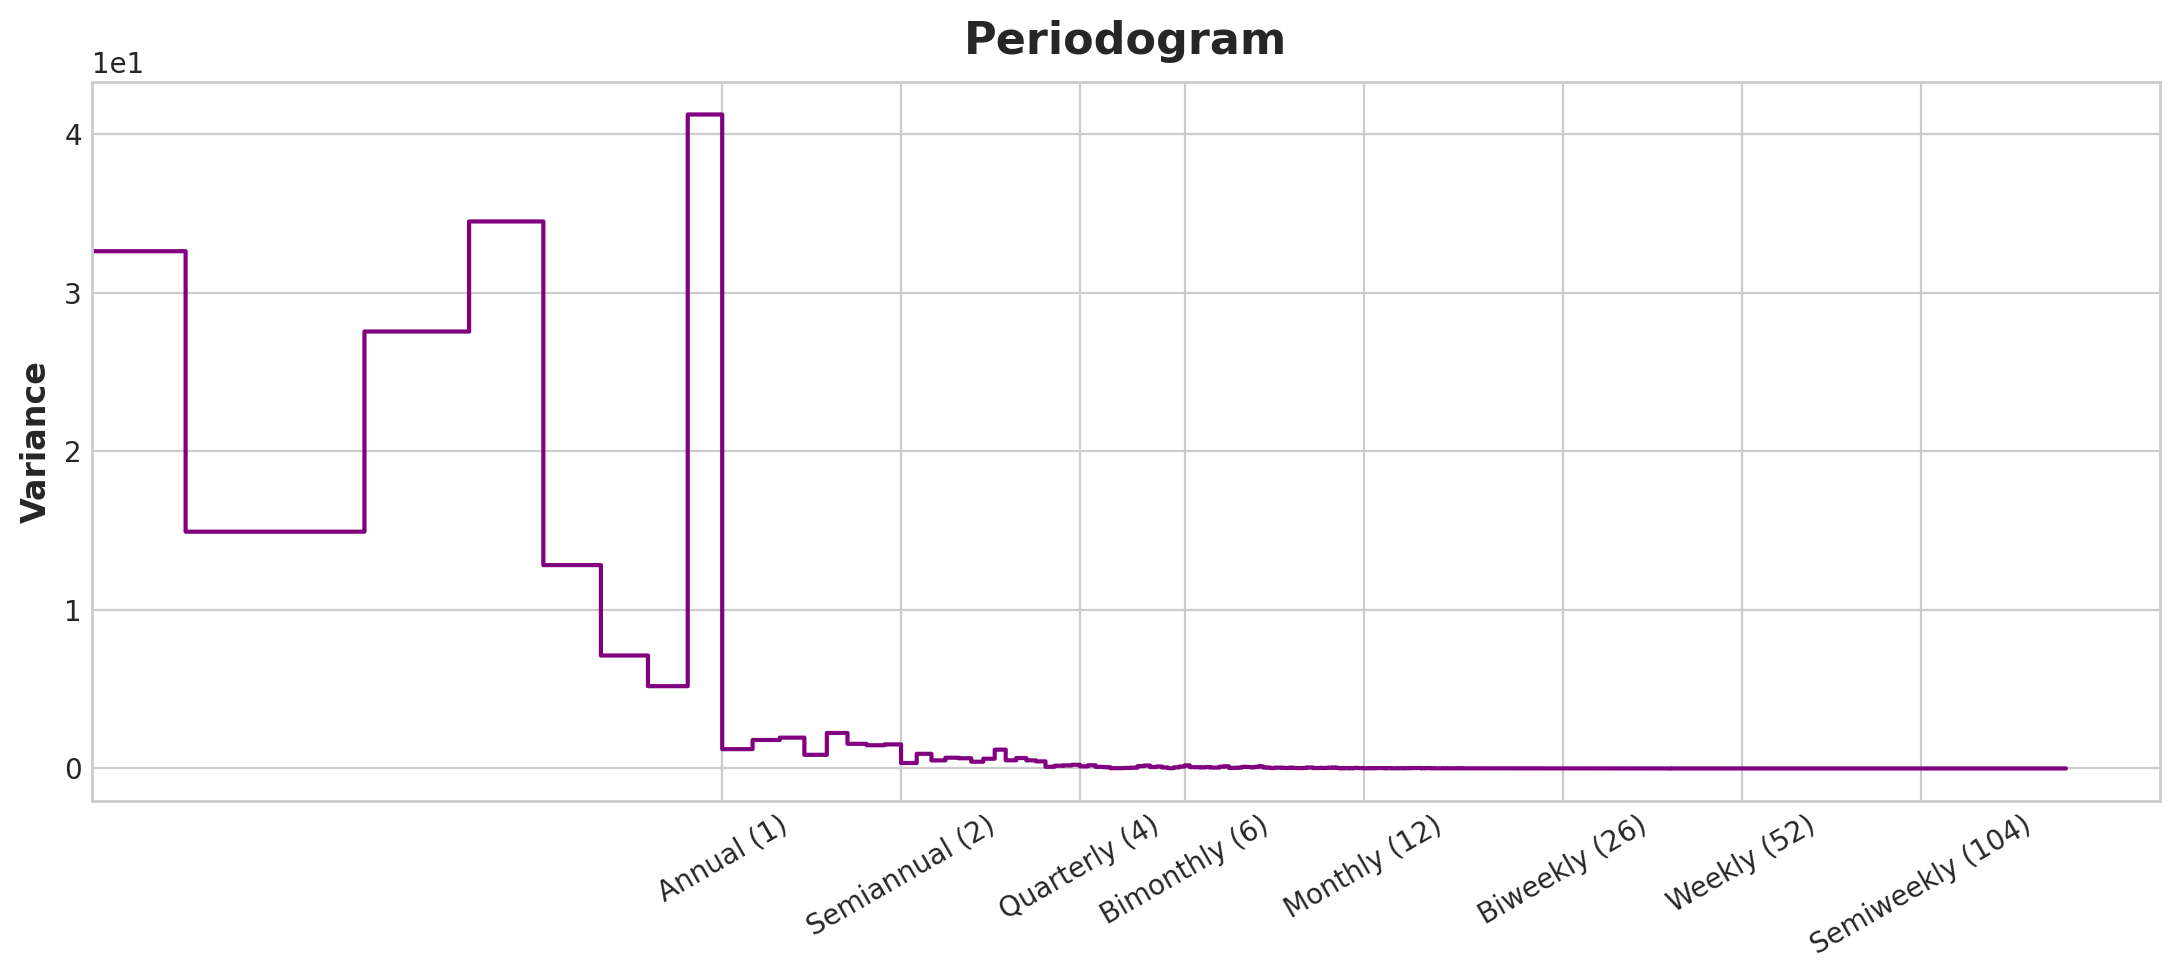

In [77]:
plot_periodogram(df_treino.Volume_util);

In [92]:
df_treino = df_treino.asfreq('D')
fourier = CalendarFourier(freq = "A", order = 4)

dp = DeterministicProcess(
    index=df_treino.index,
    constant=True,               # dummy feature for bias (y-intercept)
    order=1,                     # trend (order 1 means linear)
    seasonal=True,               # weekly seasonality (indicators)
    additional_terms=[fourier],  # annual seasonality (fourier)
    drop=True,                   # drop terms to avoid collinearity
)

x3_treino = dp.in_sample()

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [79]:
df_treino

,Volume_util,Time,y_pred
Data,,,
2016-01-01,0.66920,5844,48.022175
2016-01-02,1.12035,5845,48.022935
2016-01-03,1.54754,5846,48.023694
2016-01-04,1.91442,5847,48.024453
2016-01-05,2.16862,5848,48.025213
...,...,...,...
2023-12-27,72.18452,8761,50.236980
2023-12-28,72.06991,8762,50.237739
2023-12-29,71.97895,8763,50.238498


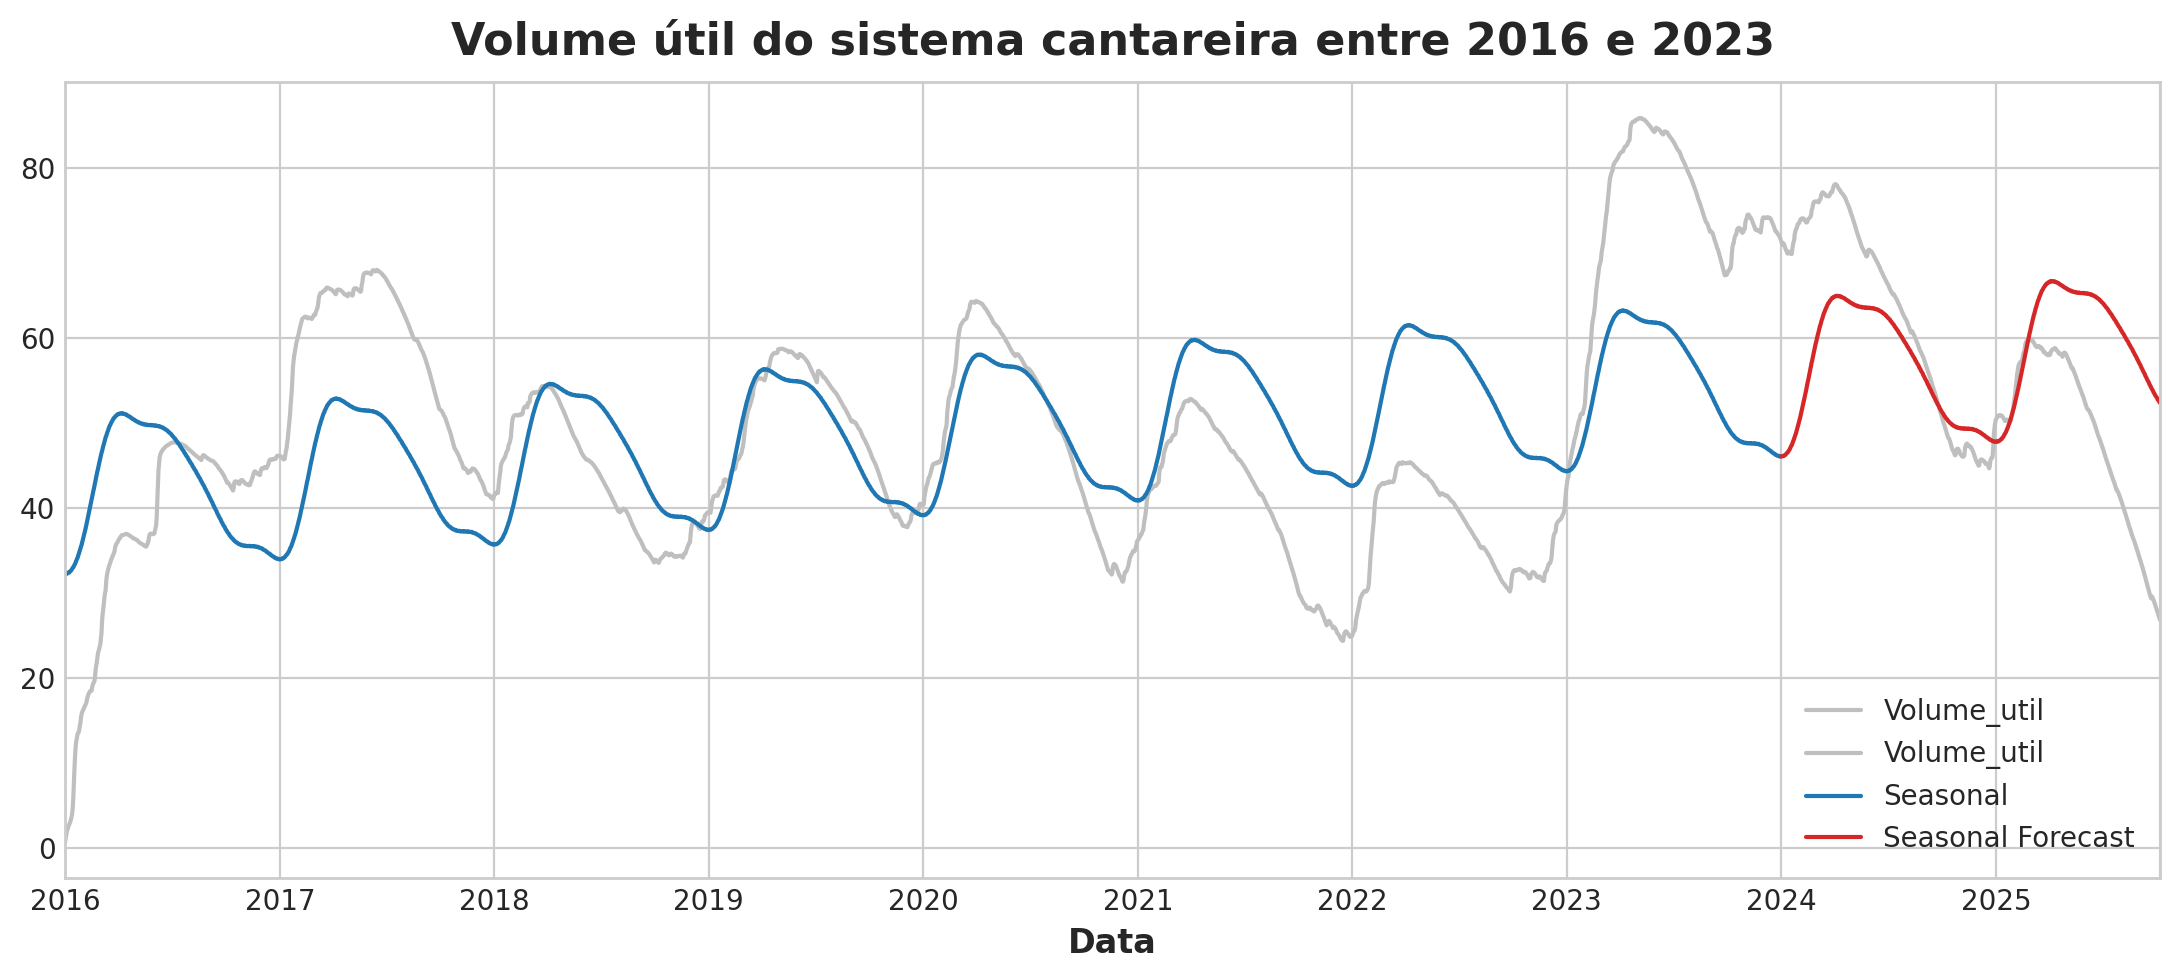

In [94]:

num_steps_para_prever = len(df_teste)
y3_treino = df_treino["Volume_util"]
y3_teste = df_teste["Volume_util"]
model3 = LinearRegression()
_ = model3.fit(x3_treino, y3_treino)

y_pred3 = pd.Series(model3.predict(x3_treino), index=y3_treino.index)
x_fore3 = dp.out_of_sample(steps = num_steps_para_prever)
y_fore3 = pd.Series(model3.predict(x_fore3), index=x_fore3.index)

ax = y3_treino.plot(color='0.75', style='-', title="Volume útil do sistema cantareira entre 2016 e 2023")
ax = df_teste['Volume_util'].plot(color='0.75', style = '-')
ax = y_pred3.plot(ax=ax, label="Seasonal")
ax = y_fore3.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()

In [95]:
y_res_pred3 = y3_treino - y_pred3
y_res_fore3 = y3_teste - y_fore3

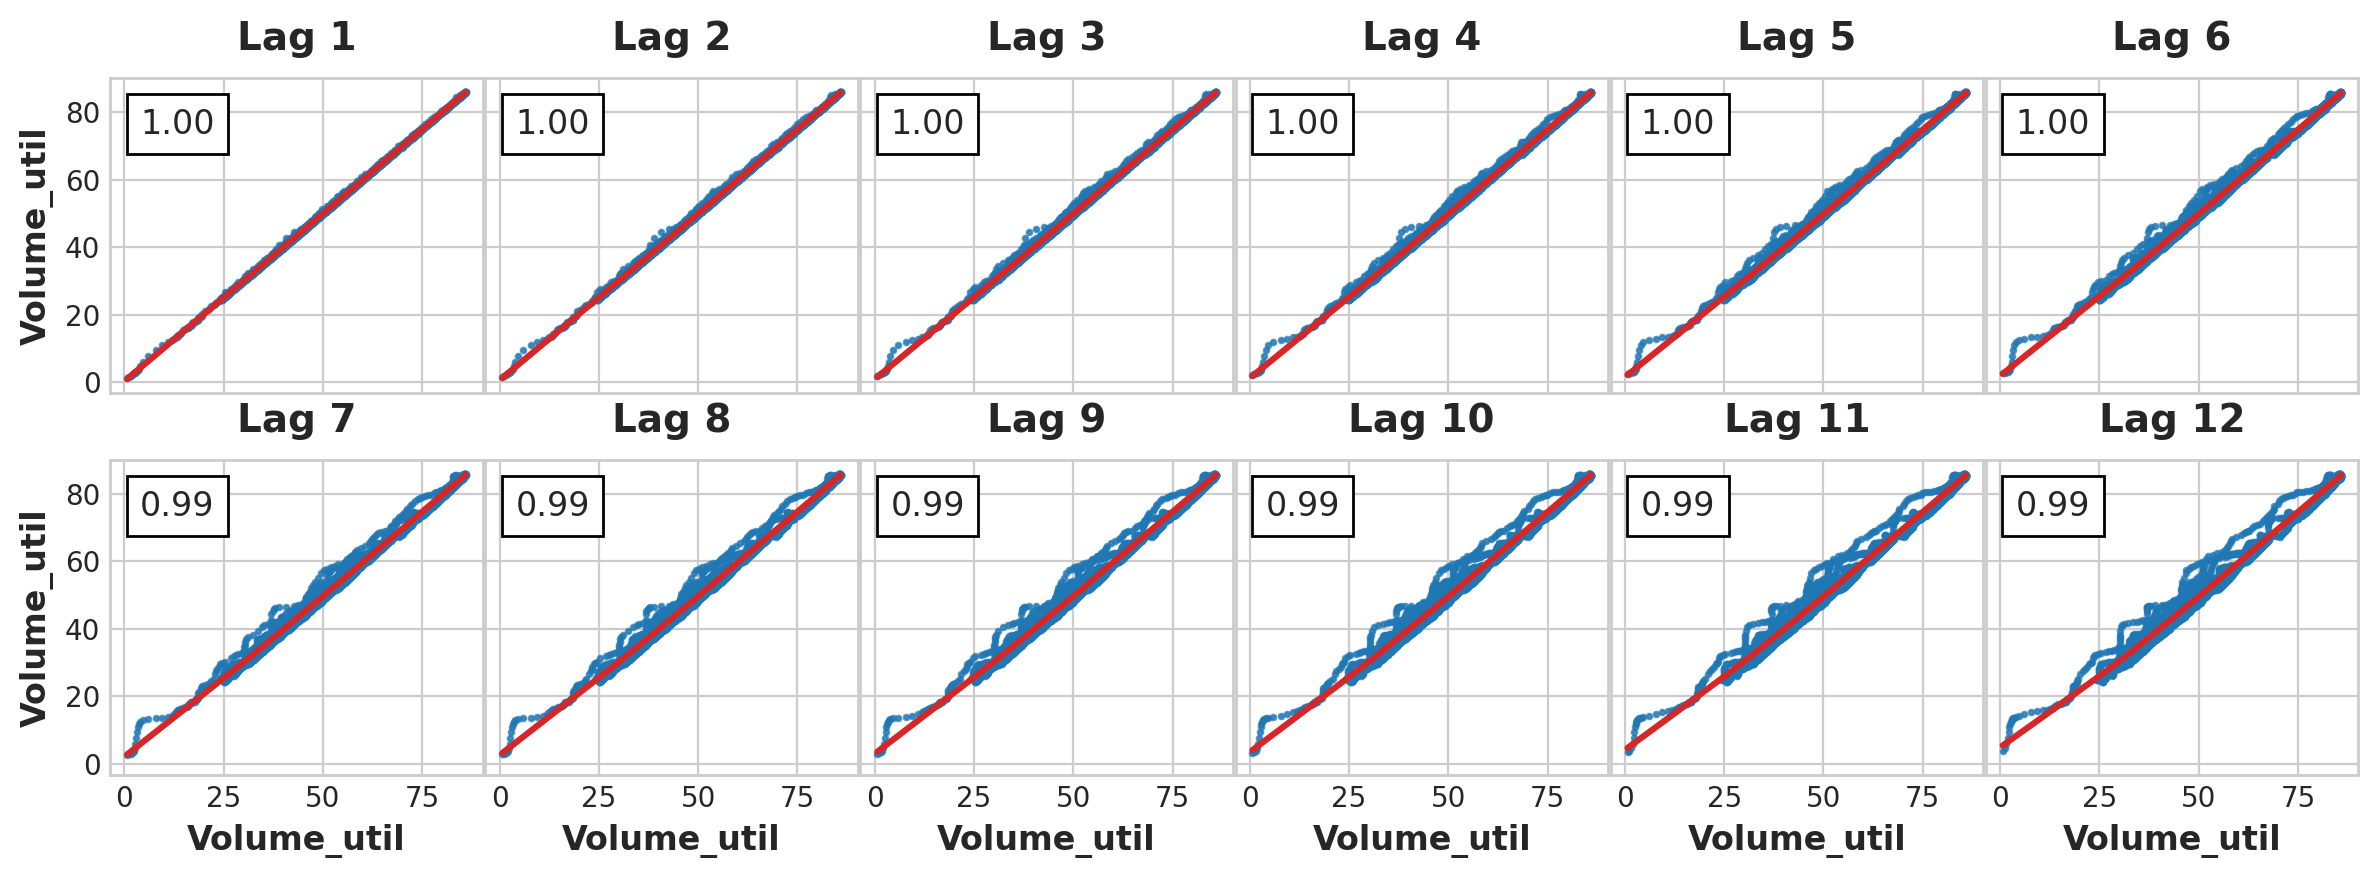

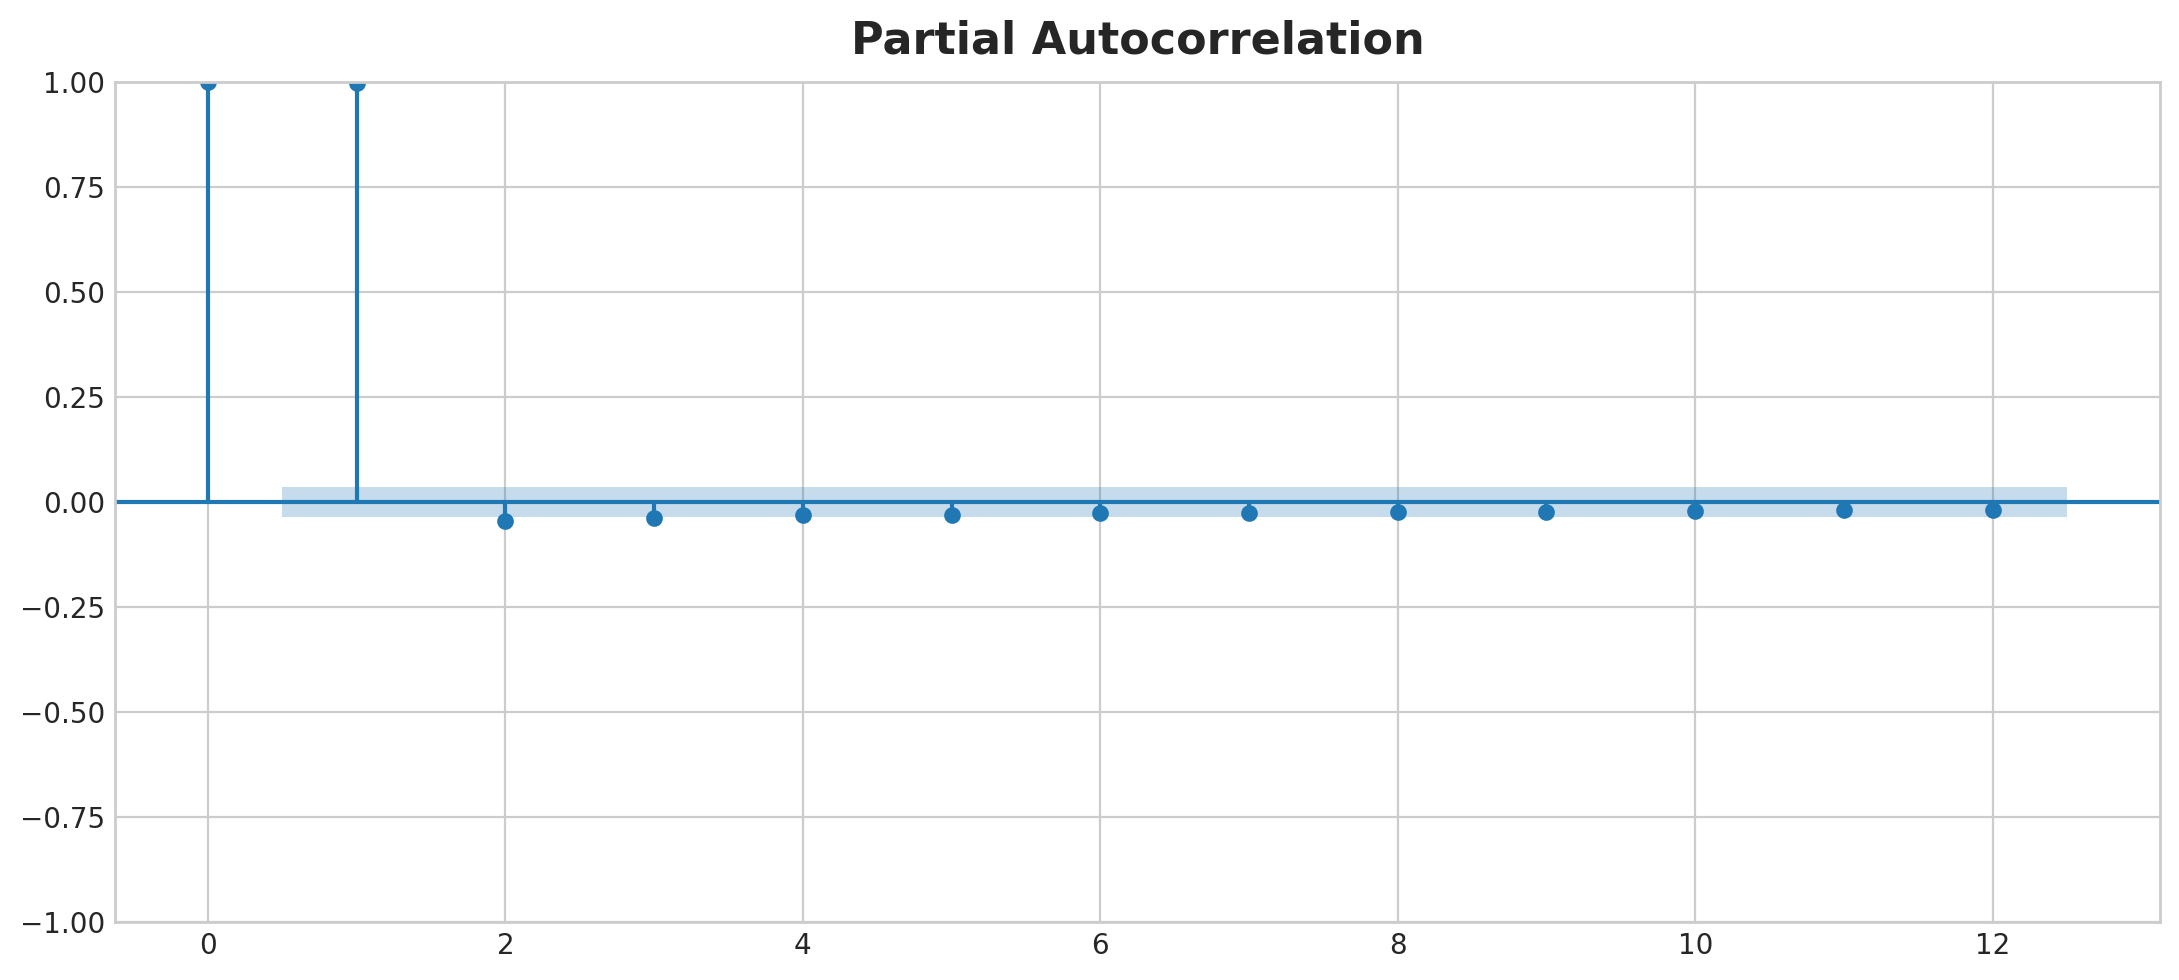

In [83]:
_ = plot_lags(df_treino.Volume_util, lags=12, nrows=2)
_ = plot_pacf(df_treino.Volume_util, lags=12)

In [96]:
def make_lags(ts, lags):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)


x4_treino = make_lags(y_res_pred3, lags=1)
x4_treino = x4_treino.fillna(0.0)

x4_teste = make_lags(y_res_fore3, lags=1)
x4_teste = x4_teste.fillna(0.0)

In [101]:
# Create target series and data splits
y4_treino = df_treino.Volume_util.copy()
y4_teste = df_teste.Volume_util.copy()
model4 = XGBRegressor(n_estimators = 50, learning_rate = 0.05, max_depth = 5 )  # `fit_intercept=True` since we didn't use DeterministicProcess
#model4 = LinearRegression(fit_intercept=True)
model4.fit(x4_treino, y_res_pred3)
y_pred_res4 = pd.Series(model4.predict(x4_treino), index=y_res_pred3.index)
y_fore_res4 = pd.Series(model4.predict(x4_teste), index=y_res_fore3.index)

In [102]:
y_pred_final4 = y_pred3.loc[y_pred_res4.index] + y_pred_res4
y_fore_final4 = y_fore3.loc[y_fore_res4.index] + y_fore_res4

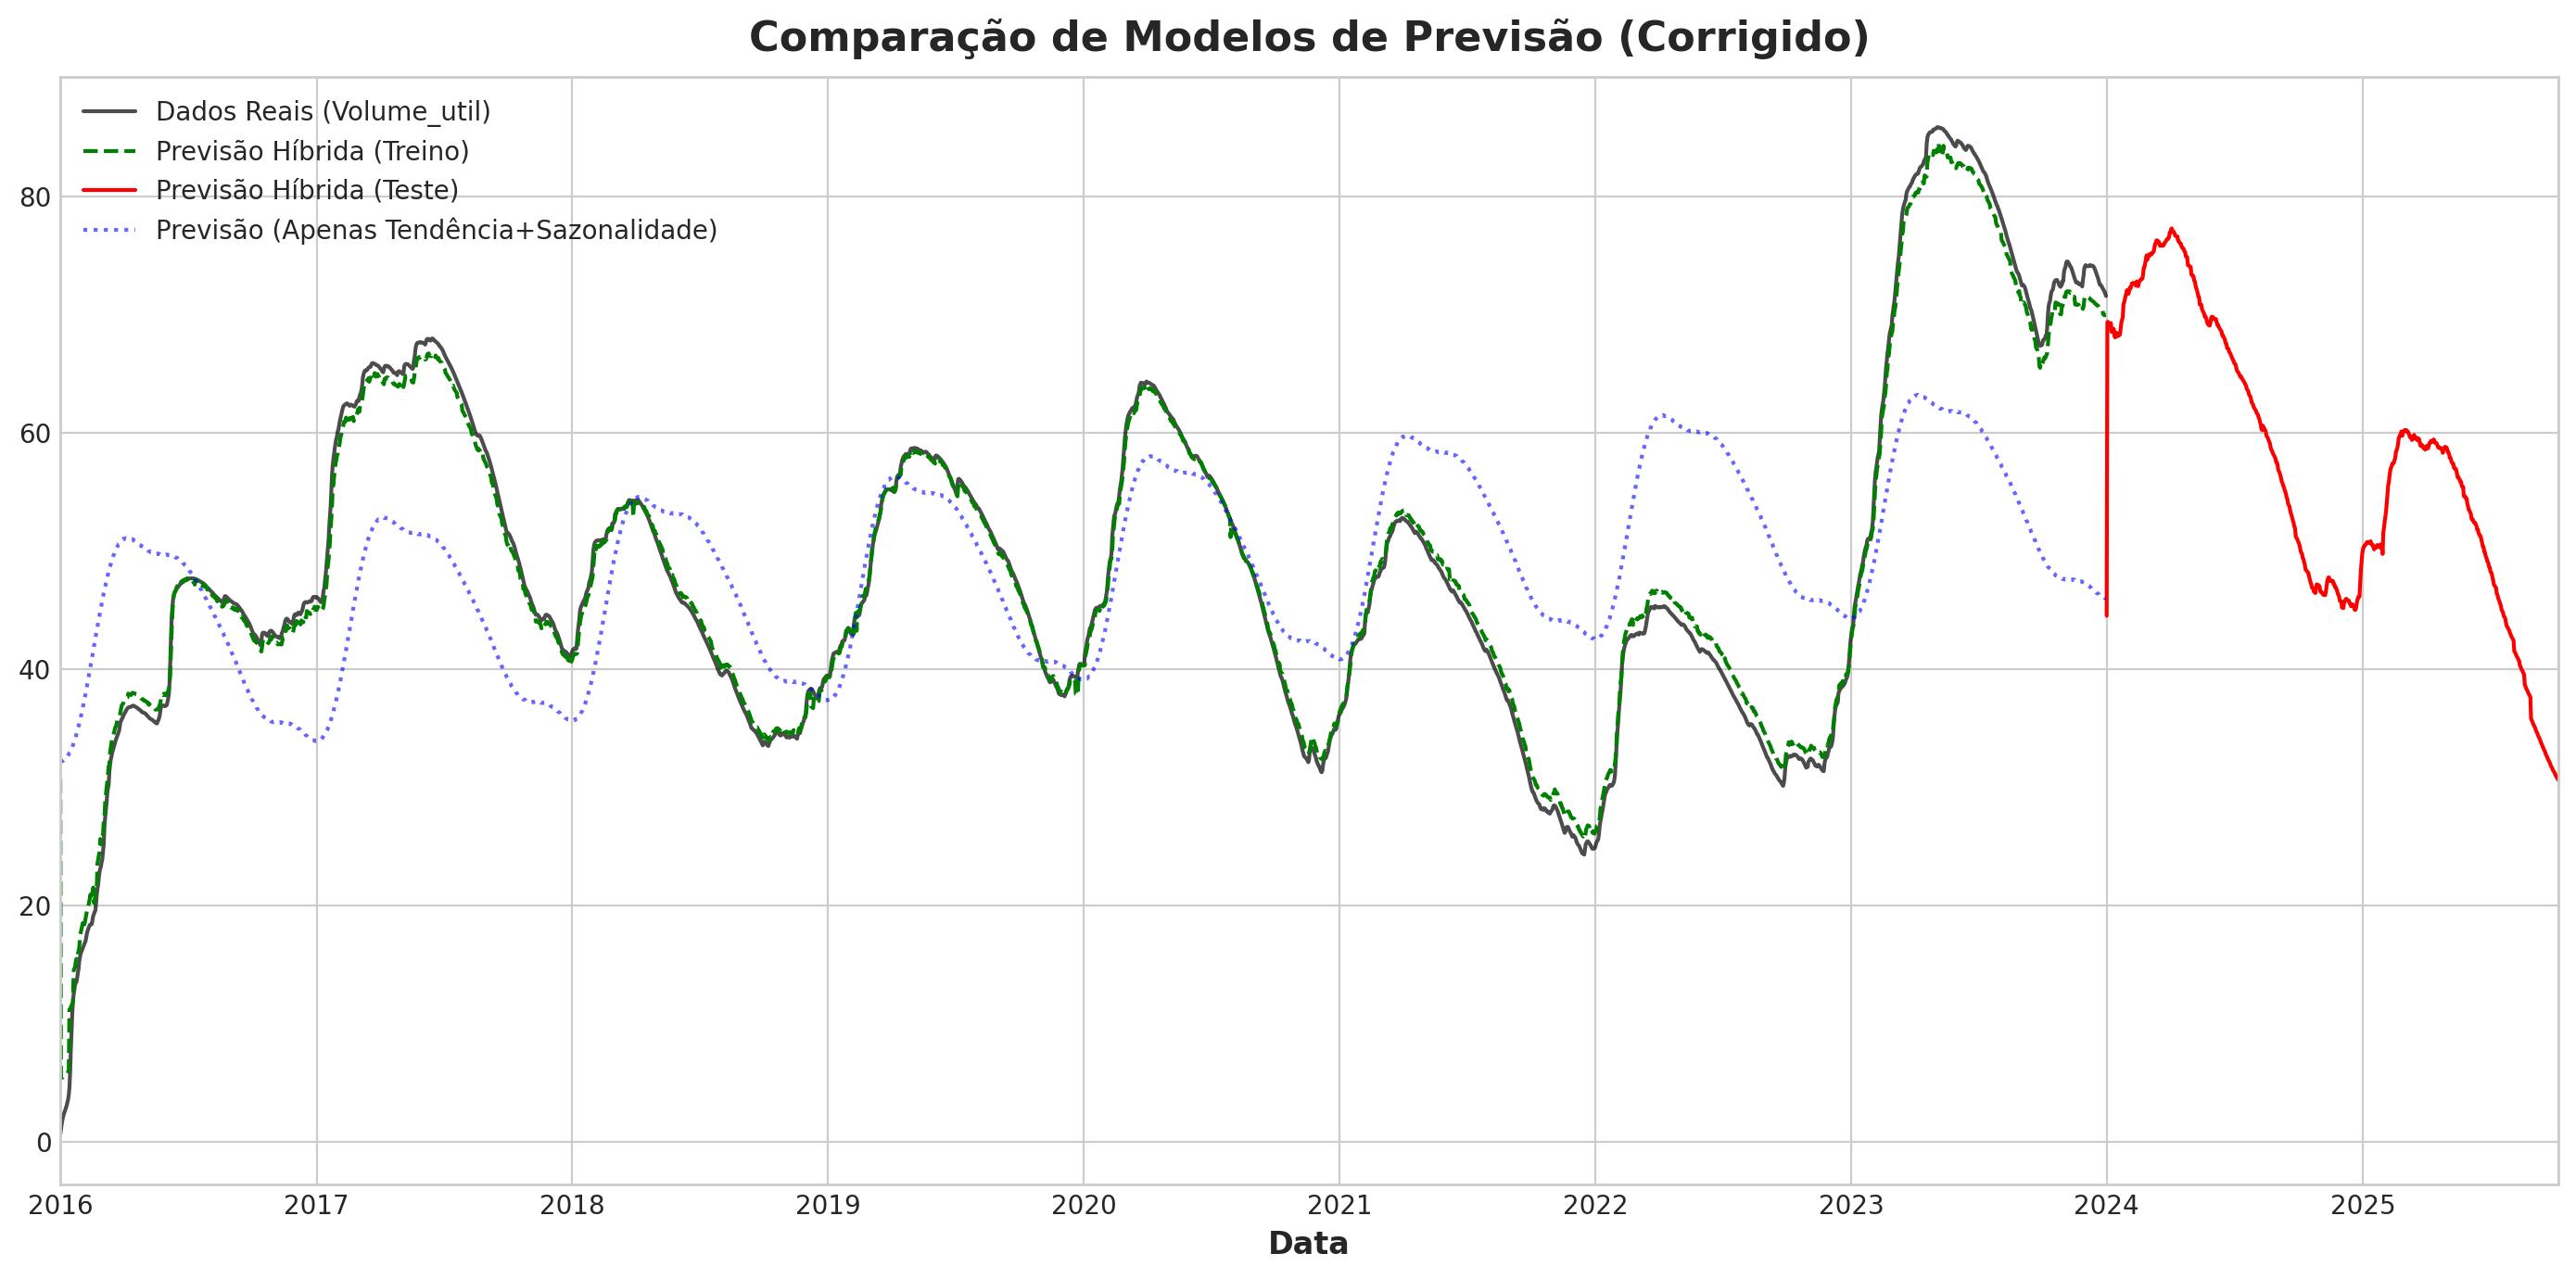

In [106]:
fig, ax = plt.subplots(figsize=(14, 7))

# Dados Reais
df_treino['Volume_util'].plot(ax=ax, color='black', alpha=0.7, style='-', label='Dados Reais (Volume_util)')

# Previsão Híbrida Final
y_pred_final4.plot(ax=ax, color='green', linestyle='--', label='Previsão Híbrida (Treino)')
y_fore_final4.plot(ax=ax, color='red', linestyle='-', label='Previsão Híbrida (Teste)')

# Previsão do Modelo 1 para referência
y_pred3.plot(ax=ax, color='blue', alpha=0.6, linestyle=':', label='Previsão (Apenas Tendência+Sazonalidade)')

ax.set_title('Comparação de Modelos de Previsão (Corrigido)')
ax.legend()
plt.show()